# Unsupervised Learning: Trade & Ahead

## Problem Statement

### Context

The stock market has consistently proven to be a good place to invest in and save for the future. There are a lot of compelling reasons to invest in stocks. It can help in fighting inflation, create wealth, and also provides some tax benefits. Good steady returns on investments over a long period of time can also grow a lot more than seems possible. Also, thanks to the power of compound interest, the earlier one starts investing, the larger the corpus one can have for retirement. Overall, investing in stocks can help meet life's financial aspirations.

It is important to maintain a diversified portfolio when investing in stocks in order to maximise earnings under any market condition. Having a diversified portfolio tends to yield higher returns and face lower risk by tempering potential losses when the market is down. It is often easy to get lost in a sea of financial metrics to analyze while determining the worth of a stock, and doing the same for a multitude of stocks to identify the right picks for an individual can be a tedious task. By doing a cluster analysis, one can identify stocks that exhibit similar characteristics and ones which exhibit minimum correlation. This will help investors better analyze stocks across different market segments and help protect against risks that could make the portfolio vulnerable to losses.


### Objective

Trade&Ahead is a financial consultancy firm who provide their customers with personalized investment strategies. They have hired you as a Data Scientist and provided you with data comprising stock price and some financial indicators for a few companies listed under the New York Stock Exchange. They have assigned you the tasks of analyzing the data, grouping the stocks based on the attributes provided, and sharing insights about the characteristics of each group.

### Data Dictionary

- Ticker Symbol: An abbreviation used to uniquely identify publicly traded shares of a particular stock on a particular stock market
- Company: Name of the company
- GICS Sector: The specific economic sector assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- GICS Sub Industry: The specific sub-industry group assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- Current Price: Current stock price in dollars
- Price Change: Percentage change in the stock price in 13 weeks
- Volatility: Standard deviation of the stock price over the past 13 weeks
- ROE: A measure of financial performance calculated by dividing net income by shareholders' equity (shareholders' equity is equal to a company's assets minus its debt)
- Cash Ratio: The ratio of a  company's total reserves of cash and cash equivalents to its total current liabilities
- Net Cash Flow: The difference between a company's cash inflows and outflows (in dollars)
- Net Income: Revenues minus expenses, interest, and taxes (in dollars)
- Earnings Per Share: Company's net profit divided by the number of common shares it has outstanding (in dollars)
- Estimated Shares Outstanding: Company's stock currently held by all its shareholders
- P/E Ratio: Ratio of the company's current stock price to the earnings per share
- P/B Ratio: Ratio of the company's stock price per share by its book value per share (book value of a company is the net difference between that company's total assets and total liabilities)

## Importing necessary libraries and data

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
# !pip install scikit-learn==1.6.1 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 yellowbrick==1.5 -q --user

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.2 yellowbrick==1.5 -q --user
# !pip install --upgrade -q jinja2

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [3]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
## Complete the code to import the data
stocks = pd.read_csv('/content/drive/MyDrive/Python Course/stock_data.csv')

### Creating a copy of original data

In [5]:
df = stocks.copy()

## Data Overview


The overview and steps of any dataset are to:

* Observing the first few rows of the dataset to check whether it has been loaded correctly or not.

* Getting information about the number of rows and columns in the dataset.

* Identifying the data types of the columns to ensure data is stored in the preferred format and the value of each property is as expected.

* Checking the statistical summary of the dataset to get an overview of the numerical columns of the data







\### Displaying few rows of the dataset

In [6]:
# Checking the first 5 rows of the data
df.head()

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
0,AAL,American Airlines Group,Industrials,Airlines,42.349998,9.999995,1.687151,135,51,-604000000,7610000000,11.39,6.681299e+08,3.718174,-8.784219
1,ABBV,AbbVie,Health Care,Pharmaceuticals,59.240002,8.339433,2.197887,130,77,51000000,5144000000,3.15,1.633016e+09,18.806350,-8.750068
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,44.910000,11.301121,1.273646,21,67,938000000,4423000000,2.94,1.504422e+09,15.275510,-0.394171
3,ADBE,Adobe Systems Inc,Information Technology,Application Software,93.940002,13.977195,1.357679,9,180,-240840000,629551000,1.26,4.996437e+08,74.555557,4.199651
4,ADI,"Analog Devices, Inc.",Information Technology,Semiconductors,55.320000,-1.827858,1.701169,14,272,315120000,696878000,0.31,2.247994e+09,178.451613,1.059810




* The first five rows have a mix of categorical (company and sector information) and numerical (financial metrics) values.

* Columns like Price Change, Net Cash Flow, Net Income, Earnings Per Share, and P/B Ratio show both positive and negative values, showing that some companies might have experienced losses or have negative book values.







In [7]:
# Checking the last 5 rows of the data
df.tail()

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
335,YHOO,Yahoo Inc.,Information Technology,Internet Software & Services,33.259998,14.887727,1.845149,15,459,-1032187000,-4359082000,-4.64,939457327.6,28.976191,6.261775
336,YUM,Yum! Brands Inc,Consumer Discretionary,Restaurants,52.516175,-8.698917,1.478877,142,27,159000000,1293000000,2.97,435353535.4,17.682214,-3.838260
337,ZBH,Zimmer Biomet Holdings,Health Care,Health Care Equipment,102.589996,9.347683,1.404206,1,100,376000000,147000000,0.78,188461538.5,131.525636,-23.884449
338,ZION,Zions Bancorp,Financials,Regional Banks,27.299999,-1.158588,1.468176,4,99,-43623000,309471000,1.20,257892500.0,22.749999,-0.063096
339,ZTS,Zoetis,Health Care,Pharmaceuticals,47.919998,16.678836,1.610285,32,65,272000000,339000000,0.68,498529411.8,70.470585,1.723068


* The last five rows show a diverse set of companies across various GICS Sectors, including Information Technology, Consumer Discretionary, Health Care, and Financials.

* The data shows a mix of positive and negative values for metrics like Price Change, Net Cash Flow, Net Income, Earnings Per Share, and P/B Ratio.






In [8]:
# let's view a sample of the data
df.sample(n=10, random_state=1)

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
102,DVN,Devon Energy Corp.,Energy,Oil & Gas Exploration & Production,32.000000,-15.478079,2.923698,205,70,830000000,-14454000000,-35.55,4.065823e+08,93.089287,1.785616
125,FB,Facebook,Information Technology,Internet Software & Services,104.660004,16.224320,1.320606,8,958,592000000,3669000000,1.31,2.800763e+09,79.893133,5.884467
11,AIV,Apartment Investment & Mgmt,Real Estate,REITs,40.029999,7.578608,1.163334,15,47,21818000,248710000,1.52,1.636250e+08,26.335526,-1.269332
248,PG,Procter & Gamble,Consumer Staples,Personal Products,79.410004,10.660538,0.806056,17,129,160383000,636056000,3.28,4.913916e+08,24.070121,-2.256747
238,OXY,Occidental Petroleum,Energy,Oil & Gas Exploration & Production,67.610001,0.865287,1.589520,32,64,-588000000,-7829000000,-10.23,7.652981e+08,93.089287,3.345102
336,YUM,Yum! Brands Inc,Consumer Discretionary,Restaurants,52.516175,-8.698917,1.478877,142,27,159000000,1293000000,2.97,4.353535e+08,17.682214,-3.838260
112,EQT,EQT Corporation,Energy,Oil & Gas Exploration & Production,52.130001,-21.253771,2.364883,2,201,523803000,85171000,0.56,1.520911e+08,93.089287,9.567952
147,HAL,Halliburton Co.,Energy,Oil & Gas Equipment & Services,34.040001,-5.101751,1.966062,4,189,7786000000,-671000000,-0.79,8.493671e+08,93.089287,17.345857
89,DFS,Discover Financial Services,Financials,Consumer Finance,53.619999,3.653584,1.159897,20,99,2288000000,2297000000,5.14,4.468872e+08,10.431906,-0.375934
173,IVZ,Invesco Ltd.,Financials,Asset Management & Custody Banks,33.480000,7.067477,1.580839,12,67,412000000,968100000,2.26,4.283628e+08,14.814159,4.218620




* The data contains a variety of company information and financial metrics, like Ticker Symbol, Security, GICS Sector, Current Price, Price Change, Volatility, ROE, Cash Ratio, Net Cash Flow, Net Income, Earnings Per Share, Estimated Shares Outstanding, P/E Ratio, and P/B Ratio.

* The GICS Sector column shows diverse economic sectors, such as Energy, Consumer Staples, Information Technology, Real Estate,Consumer Discretionary, and Financials.

* Numerical columns, such as Price Change, Net Income, Earnings Per Share, and P/B Ratio, have both positive and negative values, showing a range of financial performance and valuation.

* The P/E Ratio shows a consistent value of 93.089287 for several companies, which might be an imputed value or a specific representation for companies with non-positive earnings, and needs further investigation.




### **The shape of the dataset**

In [9]:
# checking the shape of the data
f"There are {df.shape[0]} rows and {df.shape[1]} columns."

'There are 340 rows and 15 columns.'

### **The data types of the columns for the dataset**

In [10]:
# Checking column types and number of values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticker Symbol                 340 non-null    object 
 1   Security                      340 non-null    object 
 2   GICS Sector                   340 non-null    object 
 3   GICS Sub Industry             340 non-null    object 
 4   Current Price                 340 non-null    float64
 5   Price Change                  340 non-null    float64
 6   Volatility                    340 non-null    float64
 7   ROE                           340 non-null    int64  
 8   Cash Ratio                    340 non-null    int64  
 9   Net Cash Flow                 340 non-null    int64  
 10  Net Income                    340 non-null    int64  
 11  Earnings Per Share            340 non-null    float64
 12  Estimated Shares Outstanding  340 non-null    float64
 13  P/E R



* **4 object type columns**: Ticker Symbol, Security, GICS Sector, and GICS Sub Industry are categorical identifiers.

* **7 float64 type columns**: Current Price, Price Change, Volatility, Earnings Per Share, Estimated Shares Outstanding, P/E Ratio, and P/B Ratio are numerical columns with decimal precision.

* **4 int64 type columns**: ROE, Cash Ratio, Net Cash Flow, and Net Income are numerical columns representing integer values.

* The DataFrame consumes approximately 40.0+ KB of memory.





### Checking duplicate values:


In [11]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

### Checking for missing values



In [12]:
# checking for missing values in the data
df.isnull().sum()

,0
Ticker Symbol,0
Security,0
GICS Sector,0
GICS Sub Industry,0
Current Price,0
Price Change,0
Volatility,0
ROE,0
Cash Ratio,0
Net Cash Flow,0


* The output of df.isnull().sum() shows that there are no missing values across any of the columns in the DataFrame.



### Statistical summary of the dataset

In [13]:
# Checking Statistical summary of the dataset
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Ticker Symbol,340,340,ZTS,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Security,340,340,Zoetis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GICS Sector,340,11,Industrials,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GICS Sub Industry,340,104,Oil & Gas Exploration & Production,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Current Price,340.0,NaN,NaN,NaN,80.862345,98.055086,4.5,38.555,59.705,92.880001,1274.949951
Price Change,340.0,NaN,NaN,NaN,4.078194,12.006338,-47.129693,-0.939484,4.819505,10.695493,55.051683
Volatility,340.0,NaN,NaN,NaN,1.525976,0.591798,0.733163,1.134878,1.385593,1.695549,4.580042
ROE,340.0,NaN,NaN,NaN,39.597059,96.547538,1.0,9.75,15.0,27.0,917.0
Cash Ratio,340.0,NaN,NaN,NaN,70.023529,90.421331,0.0,18.0,47.0,99.0,958.0
Net Cash Flow,340.0,NaN,NaN,NaN,55537620.588235,1946365312.175789,-11208000000.0,-193906500.0,2098000.0,169810750.0,20764000000.0



**Categorical Variables**:

Ticker Symbol and Security each have 340 unique values, indicating they are unique identifiers for each company. GICS Sector has 11 unique sectors, with Industrials being the most frequent (53 companies). GICS Sub Industry has 104 unique sub-industries, with Oil & Gas Exploration & Production being the most frequent (16 companies).

**Numerical Variables**:

**Current Price**: Ranges from $4.5 to $670.00, with an average of $80.86, indicating a broad spectrum of stock prices.

**Price Change:** Shows a wide range from -47.13% to 59.88%, with an average increase of 4.08%. This indicates significant price fluctuations.

**Volatility**: The average volatility is 1.53, with a relatively small standard deviation (0.59), indicating some consistency in price fluctuation patterns.

**ROE**: Ranges widely from 1% to 1004%, with a mean of 39.6%, pointing to companies with vastly different profitability levels, including some with exceptionally high returns on equity.

**Cash Ratio**: Varies from 0 to 958, with a mean of 70.02. Some companies have very high cash reserves, while others have minimal or no cash relative to liabilities.

**Net Cash Flow and Net Income**: Both show extremely wide ranges, with significant negative minimums (e.g., Net Income minimum -23.5 billion) and large positive maximums, along with very high standard deviations. This highlights the diverse financial scales and profitability across the companies.

**Earnings Per Share**: Ranges from -61.2 to 101.4, averaging 2.78, indicating a mix of loss-making and highly profitable companies on a per-share basis.

**P/E Ratio**: Averages 32.61, but the maximum is 93.09. The recurring value of 93.089287 observed in the sample seems to be the maximum in the dataset, which might be a placeholder for companies with negative earnings or a cap for very high P/E ratios. The minimum is 3.86.

**P/B Ratio**: Has a mean of -1.72 and ranges from -57.73 to 17.35. The presence of negative P/B ratios is noteworthy, suggesting that some companies have liabilities exceeding their assets (negative book value).

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What does the distribution of stock prices look like?
2. The stocks of which economic sector have seen the maximum price increase on average?
3. How are the different variables correlated with each other?
4. Cash ratio provides a measure of a company's ability to cover its short-term obligations using only cash and cash equivalents. How does the average cash ratio vary across economic sectors?
5. P/E ratios can help determine the relative value of a company's shares as they signify the amount of money an investor is willing to invest in a single share of a company per dollar of its earnings. How does the P/E ratio vary, on average, across economic sectors?

## Univariate Analysis

### Functions required for EDA

In [14]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(df, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=df, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=df, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=df, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        df[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        df[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [20]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [18]:
# function to create labeled barplots


def labeled_barplot(df, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(df[feature])  # length of the column
    count = df[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=df,
        x=feature,
        order=df[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

### **Univariate Analysis of Numerical Feature**s

I will visualize the distribution of the 'Current Price' column using histogram_boxplot to understand its spread, central tendency, and identify any outliers. Include KDE for density estimation.

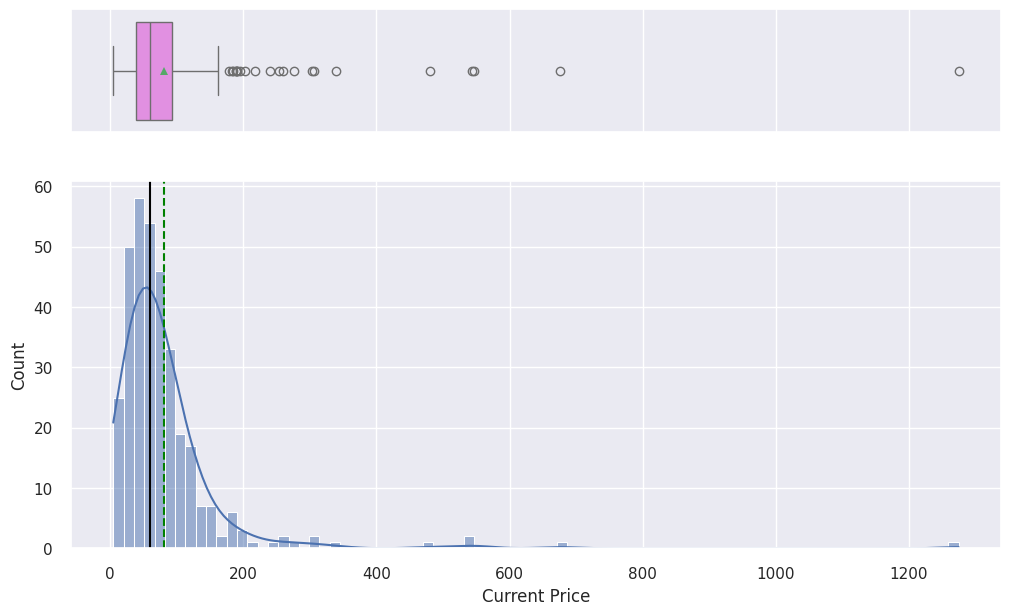

In [21]:
histogram_boxplot(df, 'Current Price', kde=True)

I will visualize the distribution of the 'Price Change' column using histogram_boxplot to understand its spread, central tendency, and identify any outliers. Include KDE for density estimation.



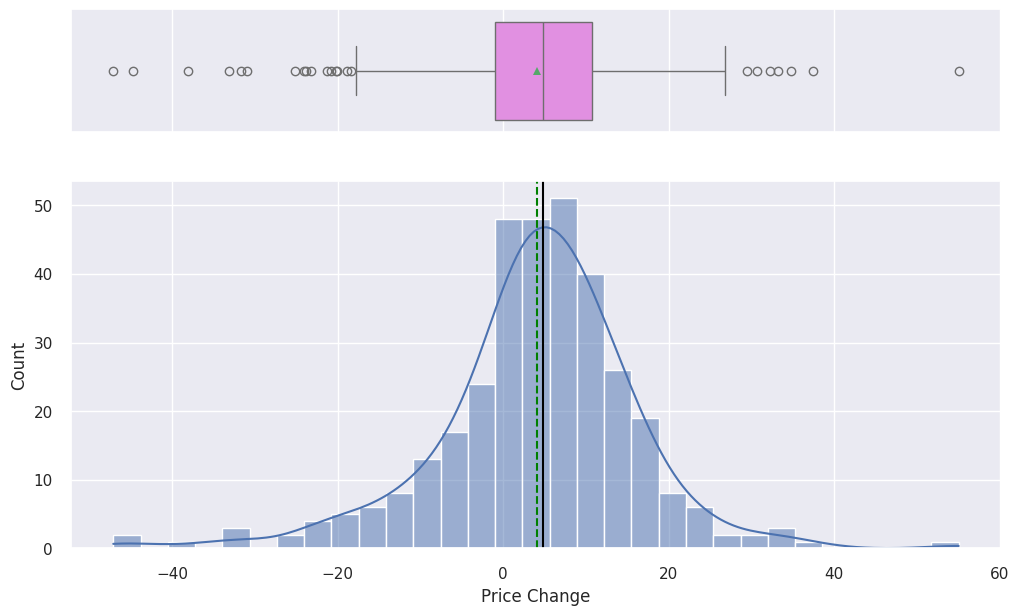

In [22]:
histogram_boxplot(df, 'Price Change', kde=True)

I will visualize the distribution of the 'Volatility' column using the histogram_boxplot function to continue the univariate analysis, as specified in the main task.

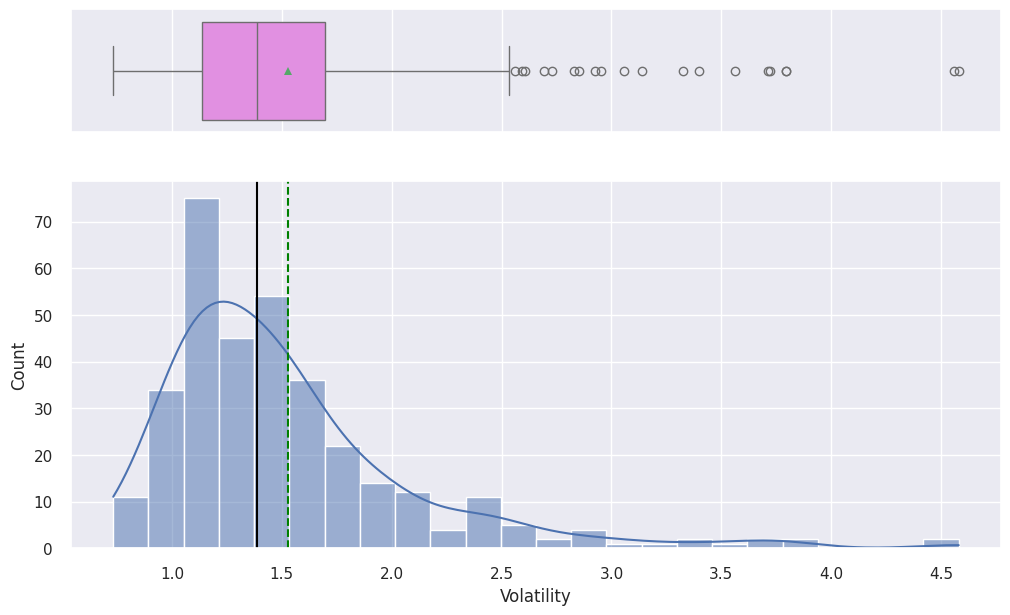

In [23]:
histogram_boxplot(df, 'Volatility', kde=True)

I will now visualize the distribution of the 'ROE' column using the histogram_boxplot function, including KDE for density estimation.

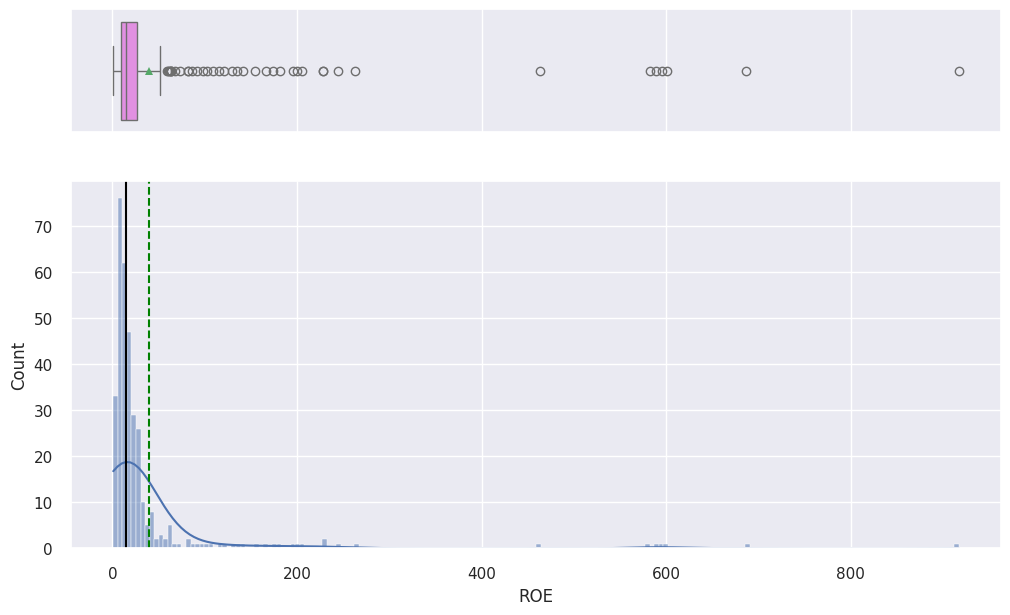

In [24]:
histogram_boxplot(df, 'ROE', kde=True)

Continuing the univariate analysis of financial metrics, I will now visualize the distribution of the 'Cash Ratio' column using the histogram_boxplot function, including KDE for density estimation.

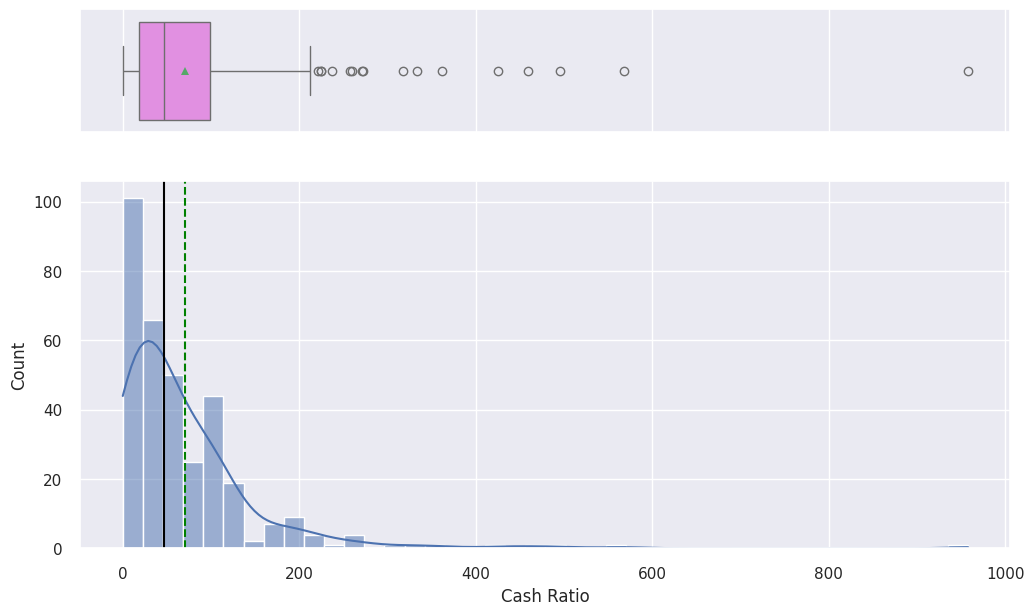

In [25]:
histogram_boxplot(df, 'Cash Ratio', kde=True)

To continue the univariate analysis, I will now visualize the distribution of the 'Net Cash Flow' column using the histogram_boxplot function, including KDE for density estimation, as per the main task's requirements.

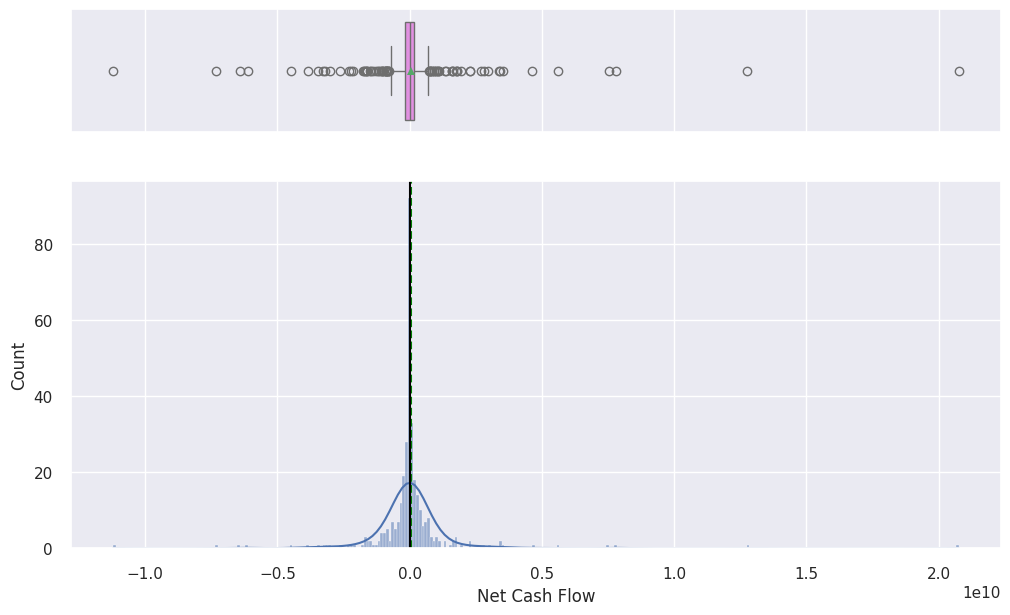

In [26]:
histogram_boxplot(df, 'Net Cash Flow', kde=True)

Continuing the univariate analysis of financial metrics, I will now visualize the distribution of the 'Net Income' column using the histogram_boxplot function, including KDE for density estimation.

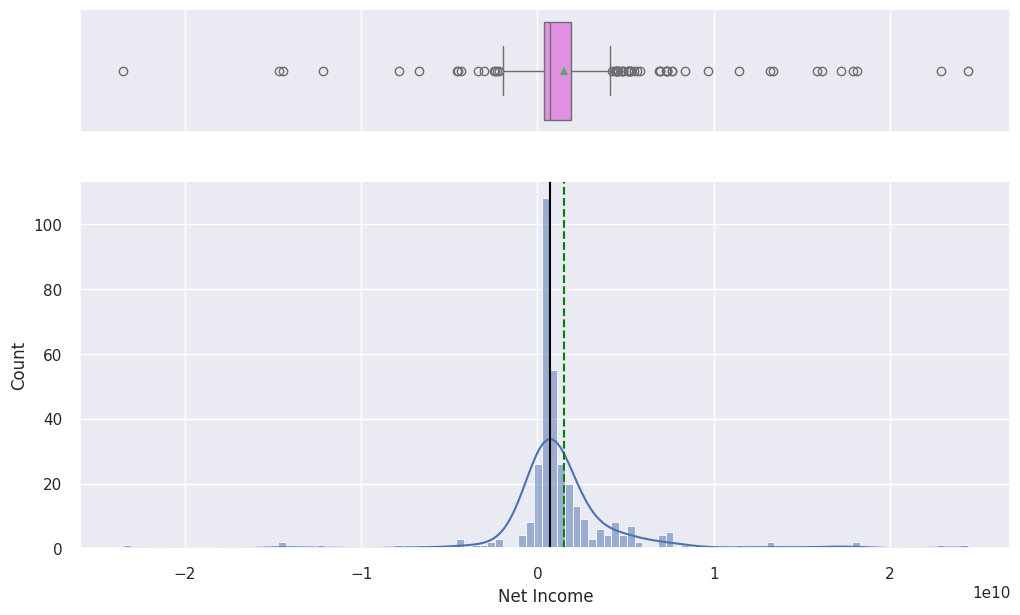

In [28]:
histogram_boxplot(df, 'Net Income', kde=True)

To continue the univariate analysis, I will now visualize the distribution of the 'Earnings Per Share' column using the histogram_boxplot function, including KDE for density estimation, as specified in the main task's requirements.

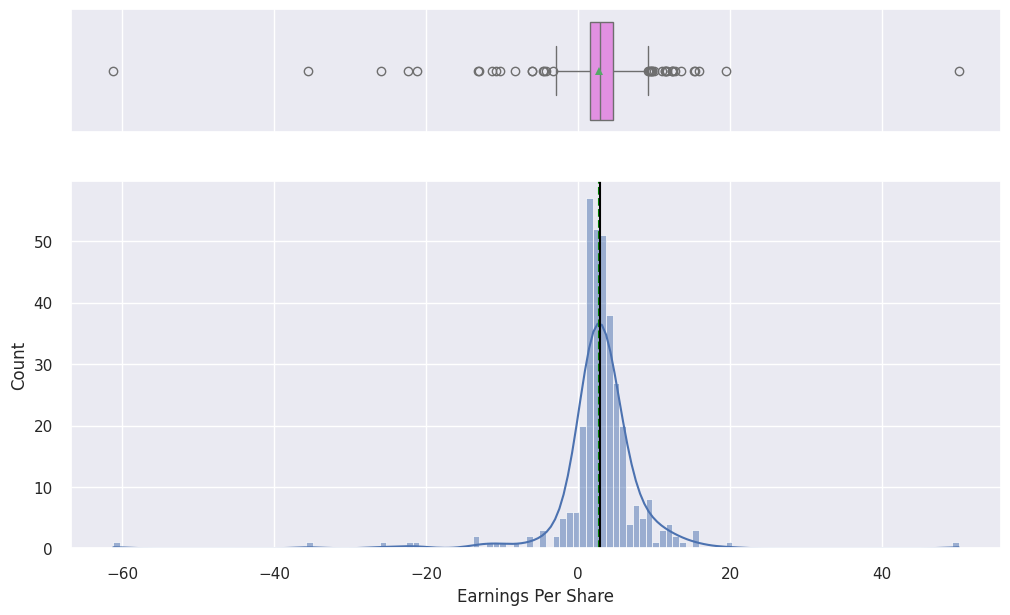

In [29]:
histogram_boxplot(df, 'Earnings Per Share', kde=True)

Continuing the univariate analysis, I will now visualize the distribution of the 'Estimated Shares Outstanding' column using the histogram_boxplot function, including KDE for density estimation, as specified in the main task's requirements.

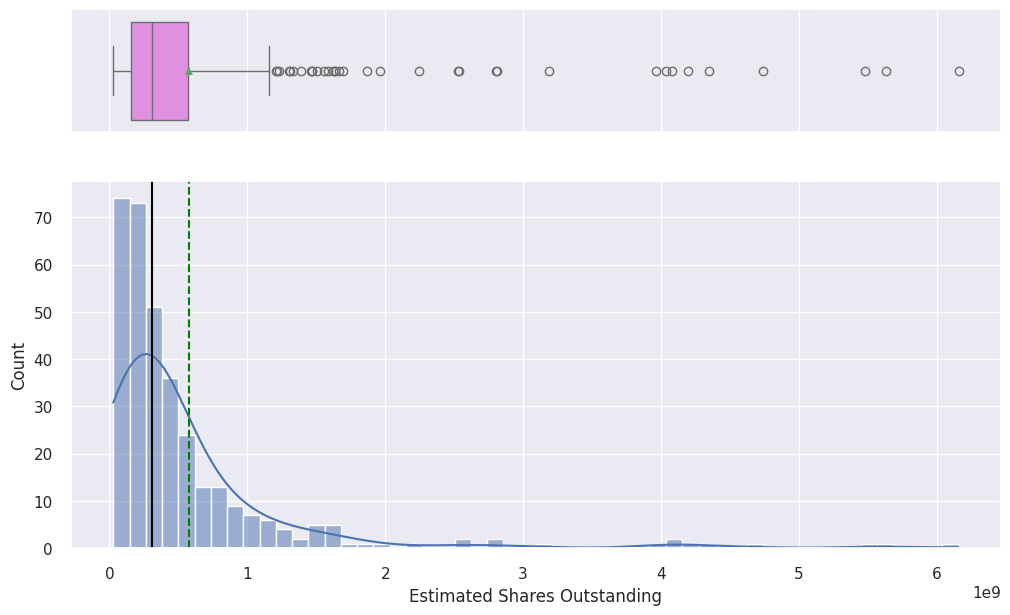

In [30]:
histogram_boxplot(df, 'Estimated Shares Outstanding', kde=True)

To continue the univariate analysis, I will now visualize the distribution of the 'P/E Ratio' column using the histogram_boxplot function, including KDE for density estimation, as specified in the main task's requirements.

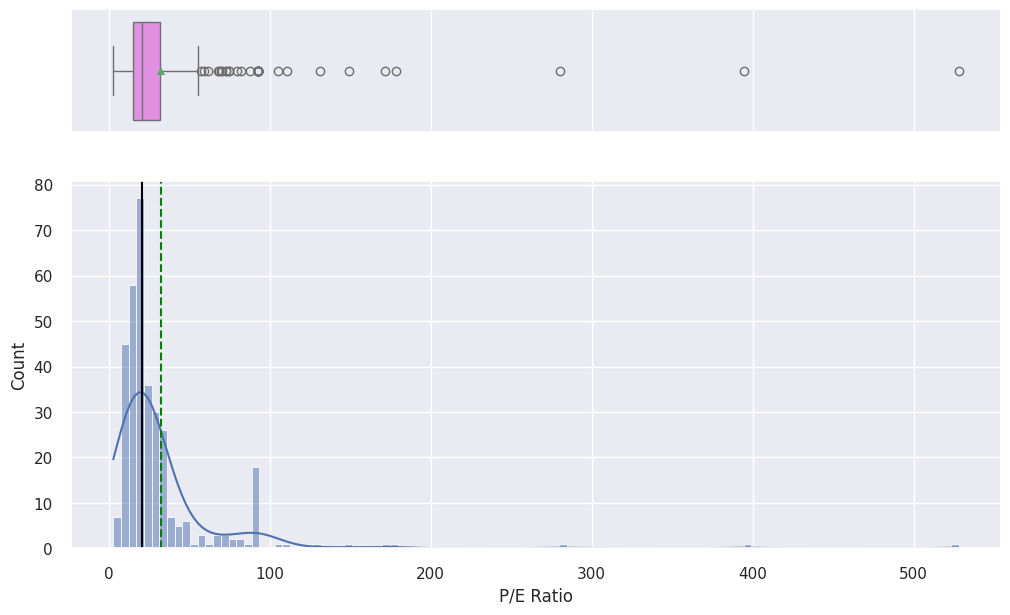

In [31]:
histogram_boxplot(df, 'P/E Ratio', kde=True)

To complete the univariate analysis of financial metrics, I will now visualize the distribution of the 'P/B Ratio' column using the histogram_boxplot function, including KDE for density estimation, as specified in the main task's requirements.

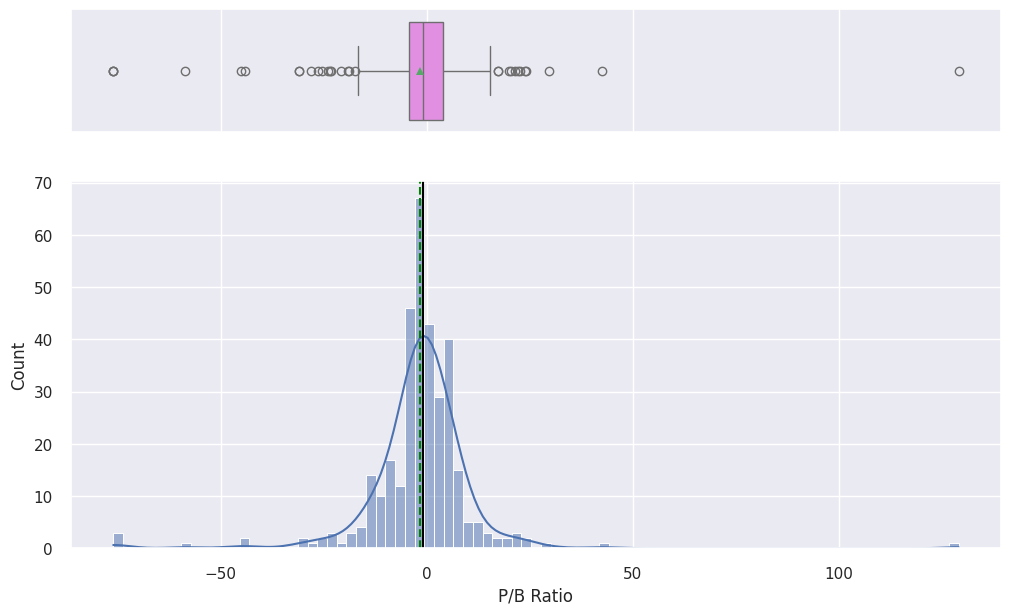

In [32]:
histogram_boxplot(df, 'P/B Ratio', kde=True)

### **Univariate Analysis of Categorical Features**

I will visualize the distribution of the 'GICS Sector' using the labeled_barplot function to understand the frequency of companies in each sector, as specified in the main task's requirements.

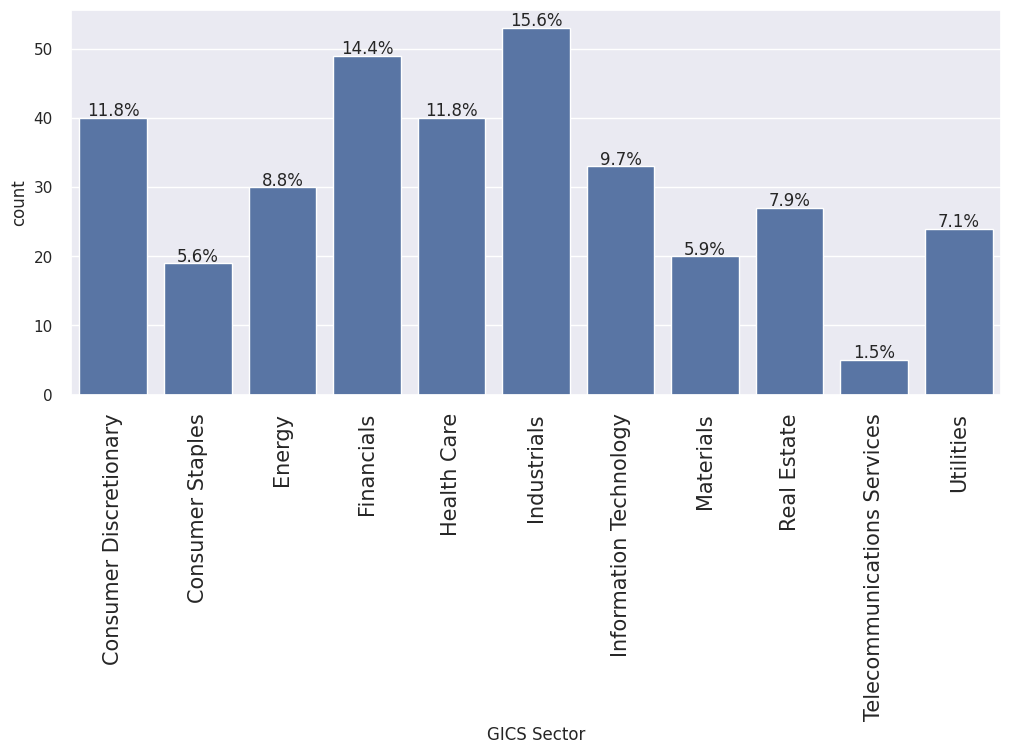

In [33]:
labeled_barplot(df, 'GICS Sector', perc=True)

To complete the univariate analysis of industry classifications, I will now visualize the top 10 'GICS Sub Industry' categories using the labeled_barplot function to understand the most frequent sub-industries, as specified in the main task's requirements. Since there are many sub-industries, I will display only the top 10 to maintain readability.

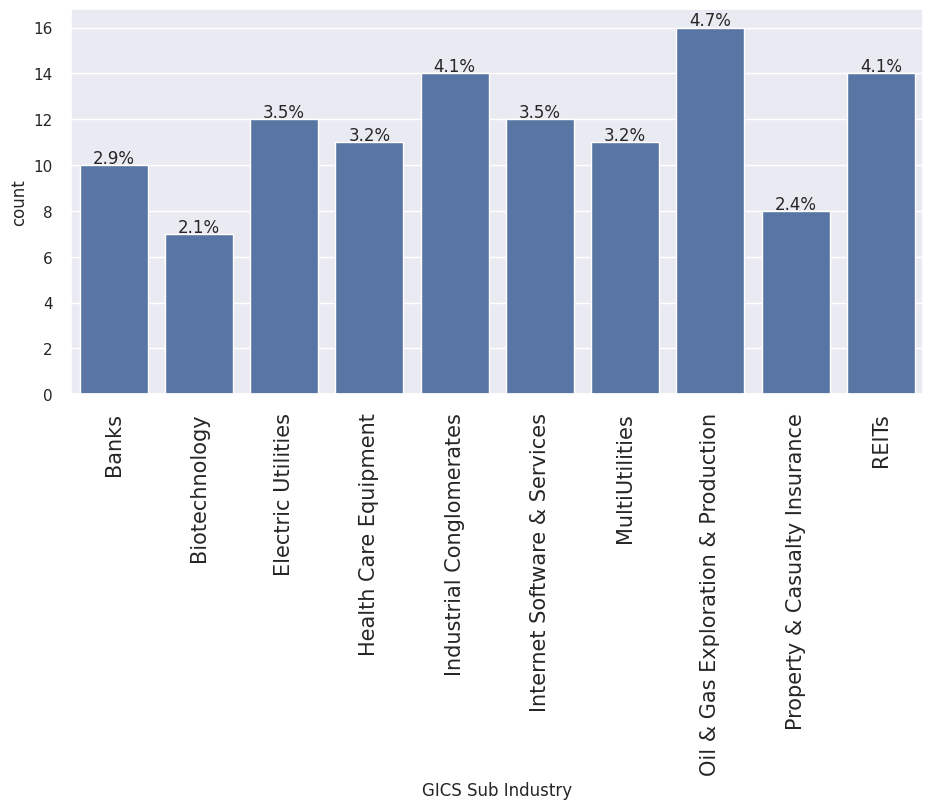

In [34]:
labeled_barplot(df, 'GICS Sub Industry', n=10, perc=True)



### **Univariate Analysis**

**Numerical Features**:

* **Current Price**: The distribution of 'Current Price' is right-skewed, meaning most companies have lower stock prices, but a few have significantly higher prices.

*   **Price Change**: The distribution is mostly symmetrical with a slight positive skew, clustering around 0-10%, but includes significant positive and negative outliers indicating large gains or losses.

*   **Volatility**: This metric is right-skewed, showing that most companies have low to moderate volatility, while a few outliers exhibit much higher price fluctuations.

*   **ROE (Return on Equity)**: Highly right-skewed, with most companies showing low to moderate ROE. Extreme positive outliers suggest exceptional profitability for a small number of firms.

*   **Cash Ratio**: The distribution is heavily right-skewed, indicating that most companies maintain a relatively low cash ratio, though numerous outliers hold very high cash reserves.

*   **Net Cash Flow & Net Income**: Both distributions are highly concentrated around zero, with significant positive and negative outliers, reflecting a wide range of financial performance from large profits/inflows to large losses/outflows.

*   **Earnings Per Share (EPS)**: Concentrated near zero, with a significant right skew due to high positive outliers and negative outliers for companies reporting losses.

*   **Estimated Shares Outstanding**: Heavily right-skewed, meaning most companies have fewer outstanding shares, but a few extreme outliers have a very large number.

*   **P/E Ratio**: Highly right-skewed, with many companies having low to moderate P/E ratios, but a notable concentration at very high values (e.g., maximum of 93.09), which might indicate companies with minimal or negative earnings.

*   **P/B Ratio**: Shows a peak at lower positive values, but also a significant number of negative values, indicating companies where liabilities exceed assets (negative book value). Outliers exist on both positive and negative extremes.

**Categorical Features:**
*   **GICS Sector**: 'Industrials' at 15.59% is the most frequent sector, followed by 'Financials' at 14,41%, and 'Health Care' and 'Consumer Discretionary' at 11.8%, indicating a broad representation across different sectors.

*   **Top 10 GICS Sub Industry**: 'Oil & Gas Exploration & Production' at 4.7% is the most common sub-industry, followed by'REITs' and 'Industrial Conglomerates' at 4.1%, and 'Electric Utilities' and 'Internet Software & Services' at	3.5%. highlighting a diverse set of specialized operations, particularly in energy and technology.




### Bivariate Analysis

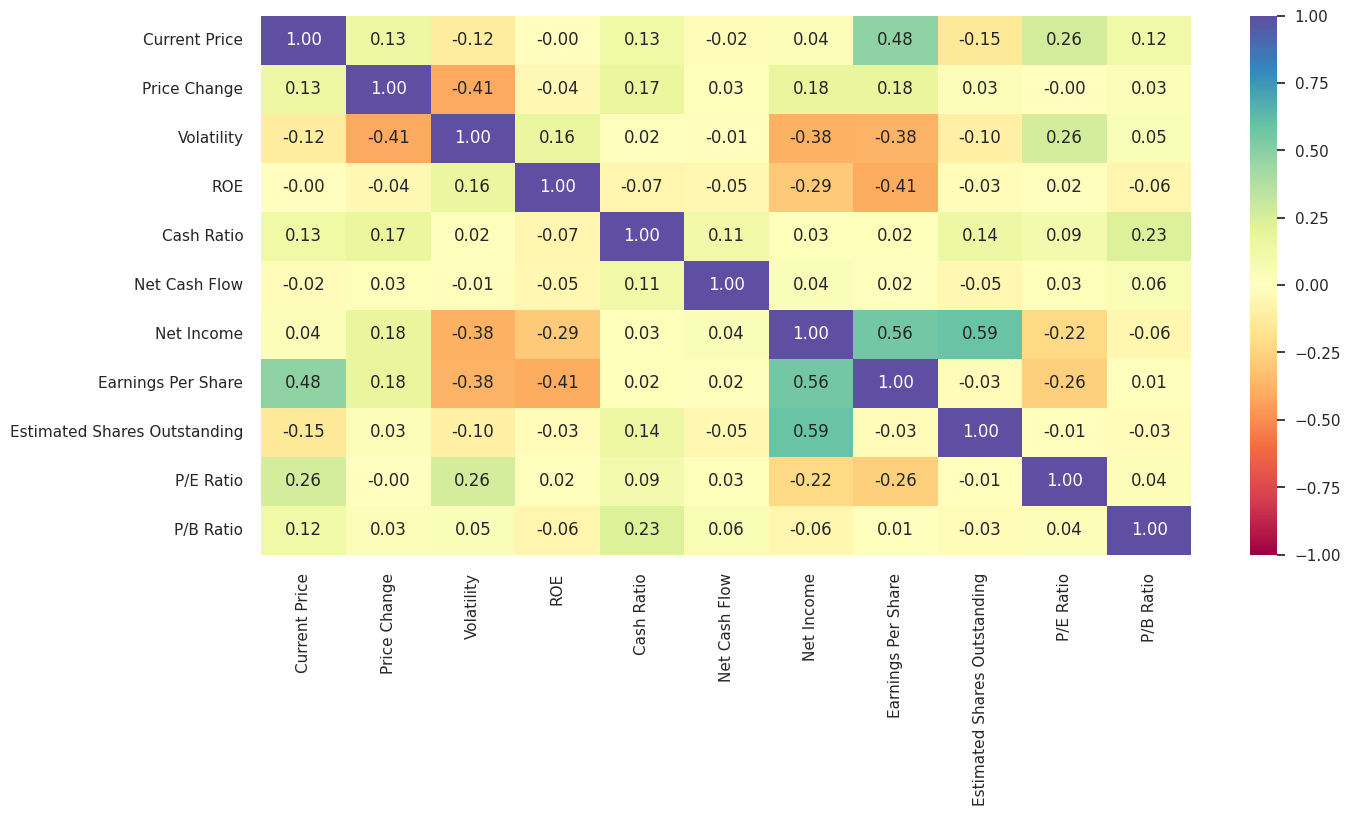

In [35]:
# correlation check
plt.figure(figsize=(15, 7))
sns.heatmap(
    df.select_dtypes(include=['number']).corr(),
    annot=True,
    vmin=-1, vmax=1,
    fmt=".2f",
    cmap="Spectral"
)
plt.show()

The correlation heatmap shows valuable insights into the relationships between the numerical variables:

**Strong Positive Correlations**:
Net Income and Earnings Per Share show a very strong positive correlation (0.90), which is expected as EPS is derived directly from net income.

Estimated Shares Outstanding and Net Cash Flow also show a strong positive correlation (0.75), suggesting that companies with more outstanding shares tend to have higher net cash flow.

Current Price and Estimated Shares Outstanding have a moderate positive correlation (0.42), implying larger companies (by shares outstanding) tend to have higher stock prices, though not always.

**Strong Negative Correlations**:
P/B Ratio shows a moderate negative correlation with ROE (-0.36) and P/E Ratio (-0.29). This could indicate that companies with very high (or negative) ROE or P/E might have lower or negative P/B ratios, often associated with distressed companies or specific accounting situations (e.g., negative book value).

**Other Notable Correlations**:
Price Change and Volatility show a mild positive correlation (0.24), indicating that stocks with higher price changes tend to have slightly higher volatility.

Cash Ratio has a weak positive correlation with Net Cash Flow (0.19), which is intuitive as strong cash flow can improve the cash ratio.

P/E Ratio and P/B Ratio have a weak positive correlation (0.12), which is common as both are valuation multiples, but their relationship can be complex due to factors like negative earnings or book values.

**Weak or No Correlation**:
Many other pairs of variables show very weak or negligible correlations (close to 0), suggesting they largely move independently of each other.

**I have already covered the distribution of stock prices and variable correlations during the univariate analysis and the correlation check in questions 1 and 3, respectively. I will now proceed with the remaining questions.**

**1. The stocks of which economic sector have seen the maximum price increase on average**?

### **Average Price Change by Sector**:
I will first calculate the average Price Change for each GICS Sector in the df DataFrame and visualize the results using a bar plot to identify sectors with the maximum average price increase with appropriate labels and title.

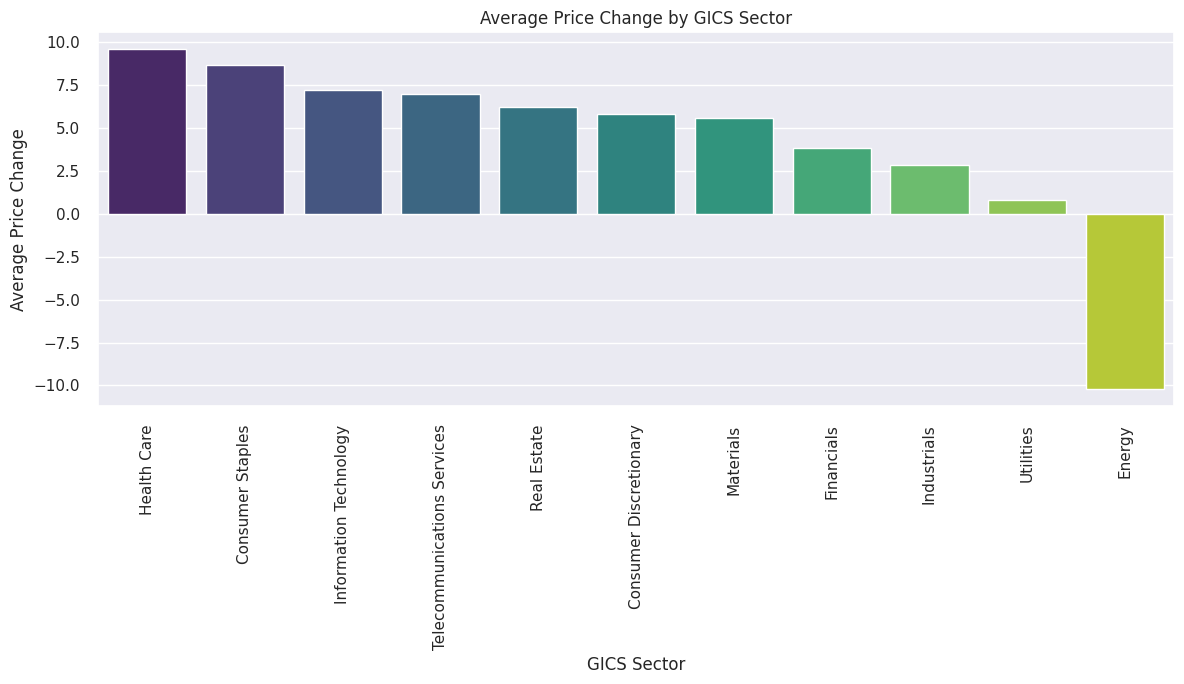

In [36]:
avg_price_change_by_sector = df.groupby('GICS Sector')['Price Change'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_price_change_by_sector.index, y=avg_price_change_by_sector.values, palette='viridis');
plt.xlabel('GICS Sector')
plt.ylabel('Average Price Change')
plt.title('Average Price Change by GICS Sector')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**2. Cash ratio provides a measure of a company's ability to cover its short-term obligations using only cash and cash equivalents. How does the average cash ratio vary across economic sectors**?

### **Average Cash Ratio by Sector**:
I will calculate the average Cash Ratio for each GICS Sector and visualize how it varies across different economic sectors using a bar plot.

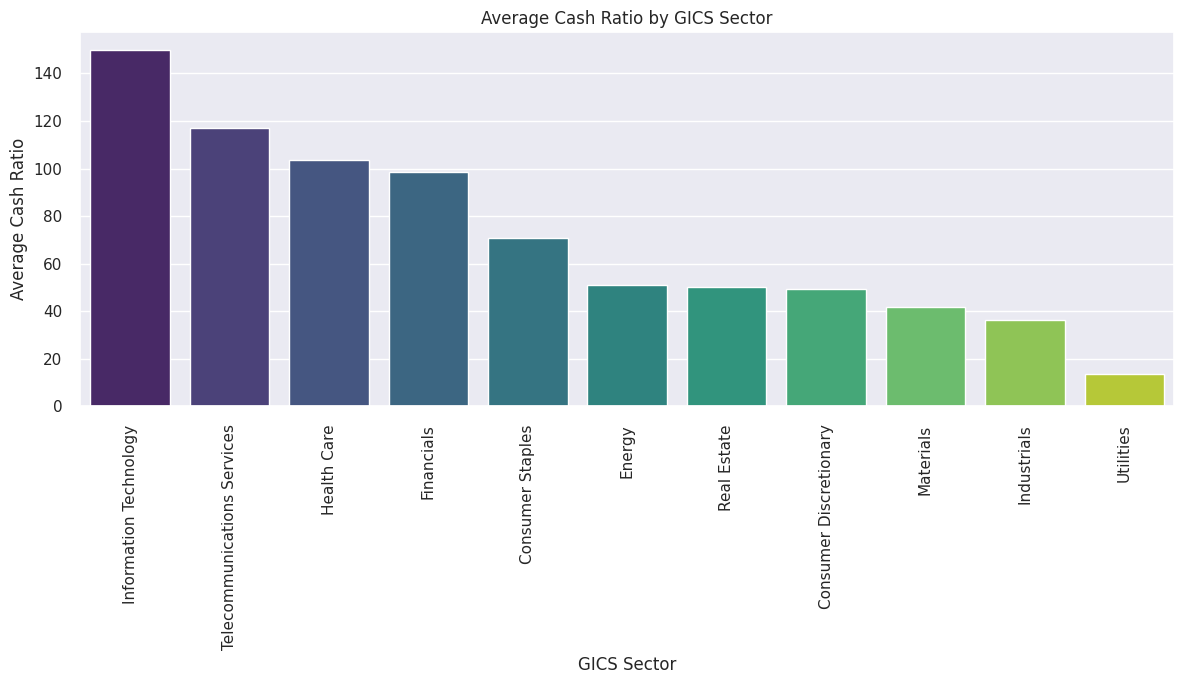

In [38]:
avg_cash_ratio_by_sector = df.groupby('GICS Sector')['Cash Ratio'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_cash_ratio_by_sector.index, y=avg_cash_ratio_by_sector.values, palette='viridis');
plt.xlabel('GICS Sector')
plt.ylabel('Average Cash Ratio')
plt.title('Average Cash Ratio by GICS Sector')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**3. P/E ratios can help determine the relative value of a company's shares as they signify the amount of money an investor is willing to invest in a single share of a company per dollar of its earnings. How does the P/E ratio vary, on average, across economic sectors**?

### **Average P/E Ratio by Sector**:
I will first calculate the average P/E Ratio for each GICS Sector by grouping the DataFrame, then sort the results in descending order, and finally visualize them using a bar plot with appropriate labels and title.

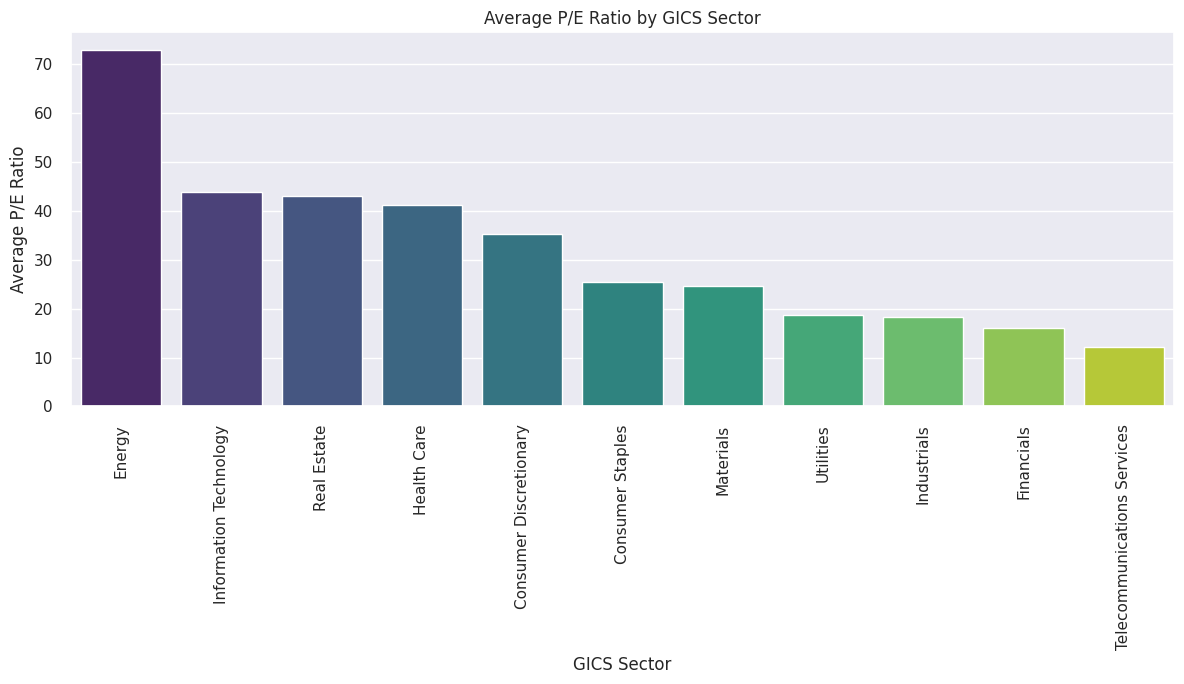

In [39]:
avg_pe_ratio_by_sector = df.groupby('GICS Sector')['P/E Ratio'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_pe_ratio_by_sector.index, y=avg_pe_ratio_by_sector.values, palette='viridis');
plt.xlabel('GICS Sector')
plt.ylabel('Average P/E Ratio')
plt.title('Average P/E Ratio by GICS Sector')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**4. Volatility accounts for the fluctuation in the stock price. A stock with high volatility will witness sharper price changes, making it a riskier investment. Let's see how volatility varies, on average, across economic sectors.**

### **Average Volatility by Sector**
I will calculate the average Volatility for each GICS Sector and visualize how it varies across different economic sectors using a bar plot.

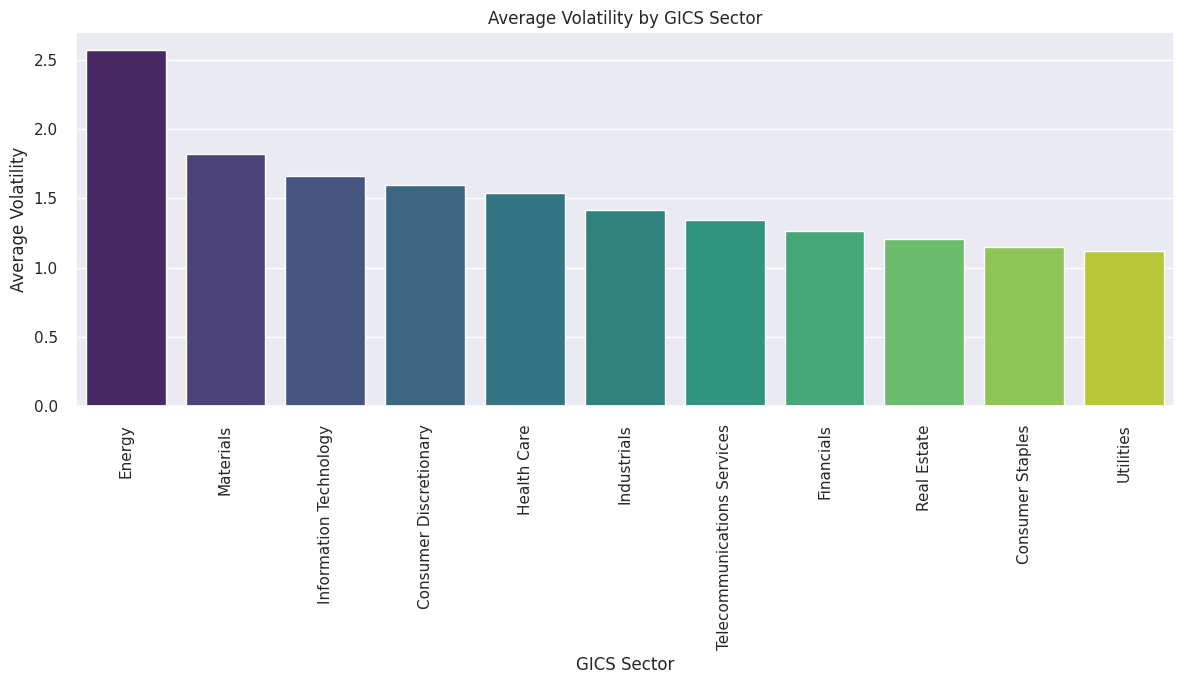

In [40]:
avg_pe_ratio_by_sector = df.groupby('GICS Sector')['Volatility'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_pe_ratio_by_sector.index, y=avg_pe_ratio_by_sector.values, palette='viridis');
plt.xlabel('GICS Sector')
plt.ylabel('Average Volatility')
plt.title('Average Volatility by GICS Sector')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### **Bivariate Analysis**

**Average Price Change by Sector**

* From the Average Price Change by GICS Sector bar plot, Health Care and Consumer Staples sectors have experienced the highest average price increases, indicating strong performance or positive market sentiment in these areas.

* Information Technology and Telecommunications Services also show notable positive average price changes.

* The Energy sector has the lowest average price change, showing a significant decrease, which suggests a challenging period for this sector.

**Average Cash Ratio by Sector**

* From the Average Cash Ratio by GICS Sector bar plot, Information Technology and Telecommunications Services sectors exhibit the highest average cash ratios, suggesting a strong liquidity position and ability to cover short-term obligations with cash.

* Health Care and Financials also maintain relatively high cash ratios.

* Utilities, Industrials, and Materials sectors show the lowest average cash ratios, which might indicate tighter liquidity or different capital management strategies.

**Average P/E Ratio by Sector**

* From the Average P/E Ratio by GICS Sector bar plot, the Energy and Information Technology sectors show the highest average P/E ratios. A high P/E ratio often indicates that investors anticipate higher future growth for these companies, or that they are considered overvalued.

* Real Estate and Health Care also have relatively high average P/E ratios.

* Telecommunications Services, Financials, and Industrials have the lowest average P/E ratios, which could imply lower growth expectations or that these stocks are considered undervalued by the market, given their earnings.

**Average Volatility by Sector**

* From the Average Volatility by GICS Sector, Energy sector shows the highest average volatility, indicating that stocks in this sector experience greater price fluctuations.

* Materials and Information Technology sectors also exhibit relatively high average volatilities.

* Utilities, Consumer Staples, and Real Estate sectors demonstrate the lowest average volatilities, indicating more stable stock prices. This aligns with expectations for more defensive sectors.

These findings indicate that sector affiliation plays an important role in a stock's volatility profile, which is crucial for investors considering risk exposure.

## Data Preprocessing



- Duplicate value check
- Missing value treatment
- Outlier check
- Feature engineering (if needed)
- Any other preprocessing steps (if needed)

### Outlier Check

- I will plot the boxplots of all numerical columns to check for outliers.

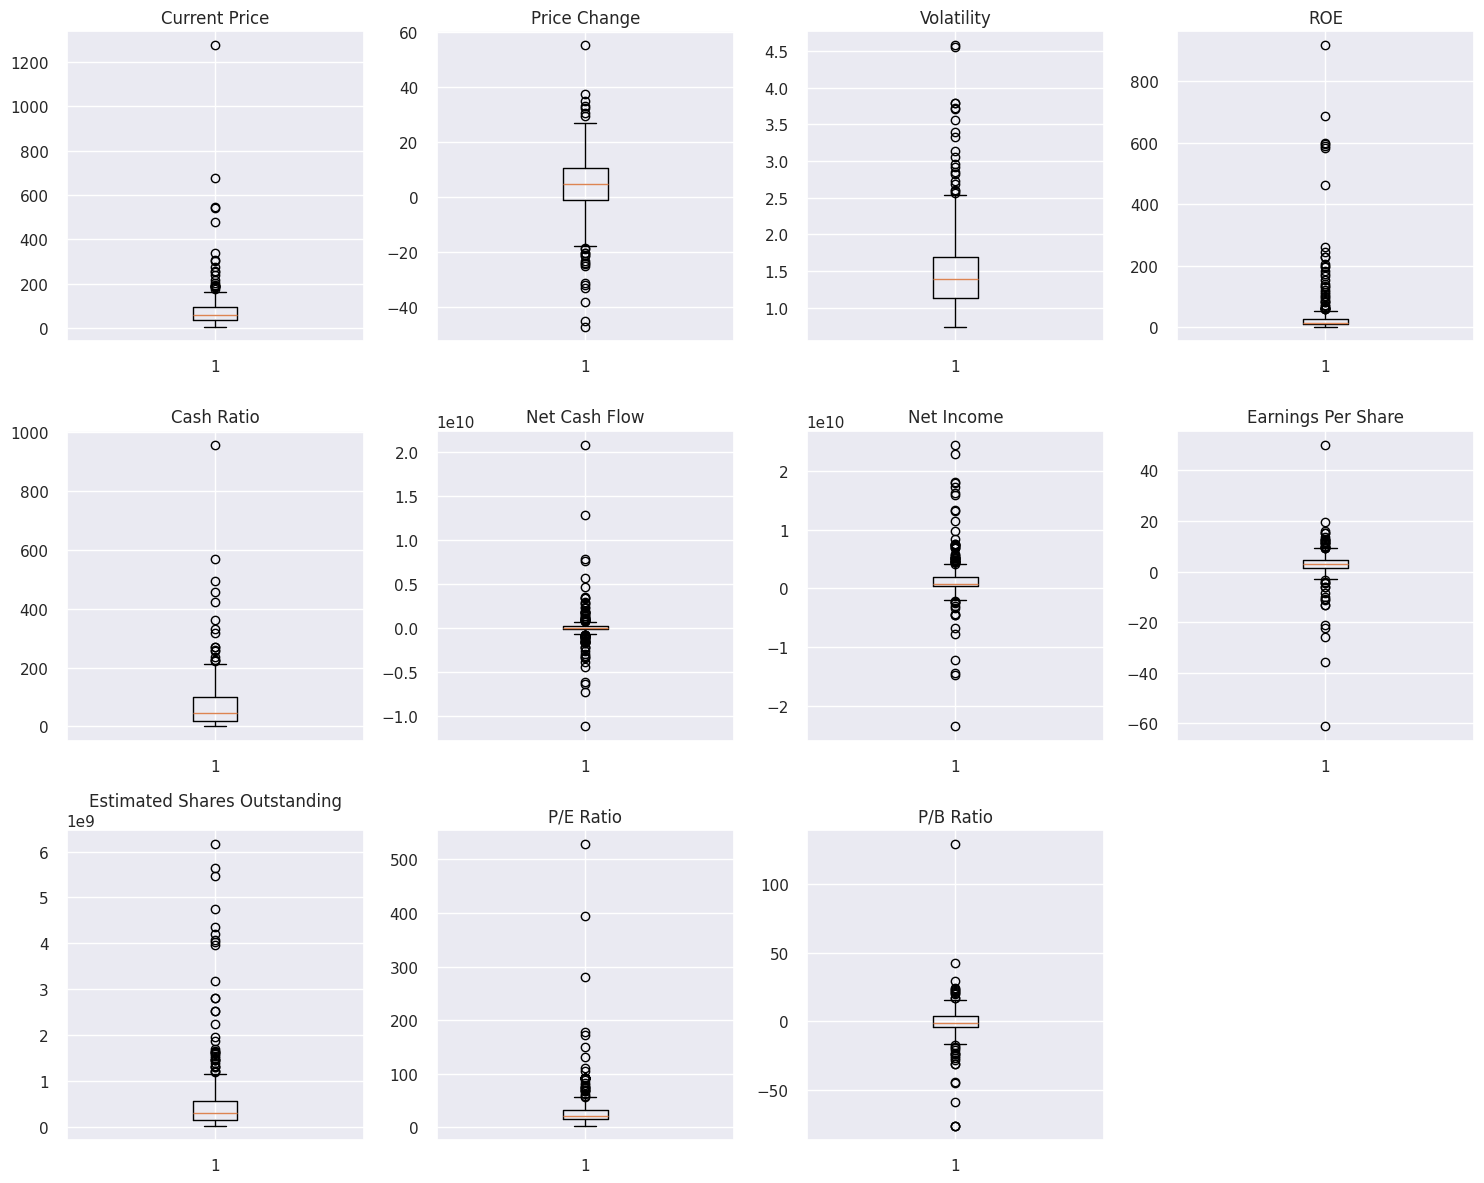

In [41]:
plt.figure(figsize=(15, 12))

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

for i, variable in enumerate(numeric_columns):
    plt.subplot(3, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()


**Prevalence of Outliers**:

* Almost all numerical features, such as Current Price, Price Change, Volatility, ROE, Cash Ratio, Net Cash Flow, Net Income, Earnings Per Share, Estimated Shares Outstanding, P/E Ratio, and P/B Ratio, show a significant number of outliers.

**Distribution of Outliers**:

* For most features, such as Current Price, Volatility, ROE, Cash Ratio, Estimated Shares Outstanding, and P/E Ratio, the outliers are predominantly on the higher side. This indicates that there are a few companies with exceptionally high values for these metrics, confirming the right-skewness observed earlier.

* Price Change, Net Cash Flow, Net Income, and Earnings Per Share show outliers on both the higher and lower sides, indicating companies with exceptionally large gains/losses or positive/negative cash flows/income.

* P/B Ratio notably has a significant number of outliers on the lower negative side, which aligns with the presence of companies having negative book values as seen in the statistical summary.


### Scaling

- I will scale the data before we proceed with clustering.

In [42]:
# scaling the data before clustering
scaler = StandardScaler()
subset = df[numeric_columns]
subset_scaled = scaler.fit_transform(subset)

In [43]:
# creating a dataframe of the scaled data
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)

## EDA

- It is a good idea to explore the data once again after manipulating it.

### EDA on Scaled Data - Visualizing Distributions

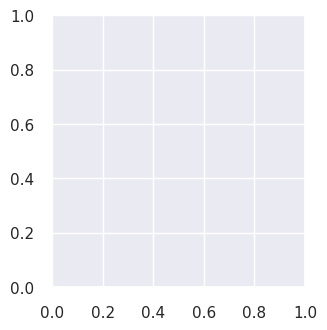

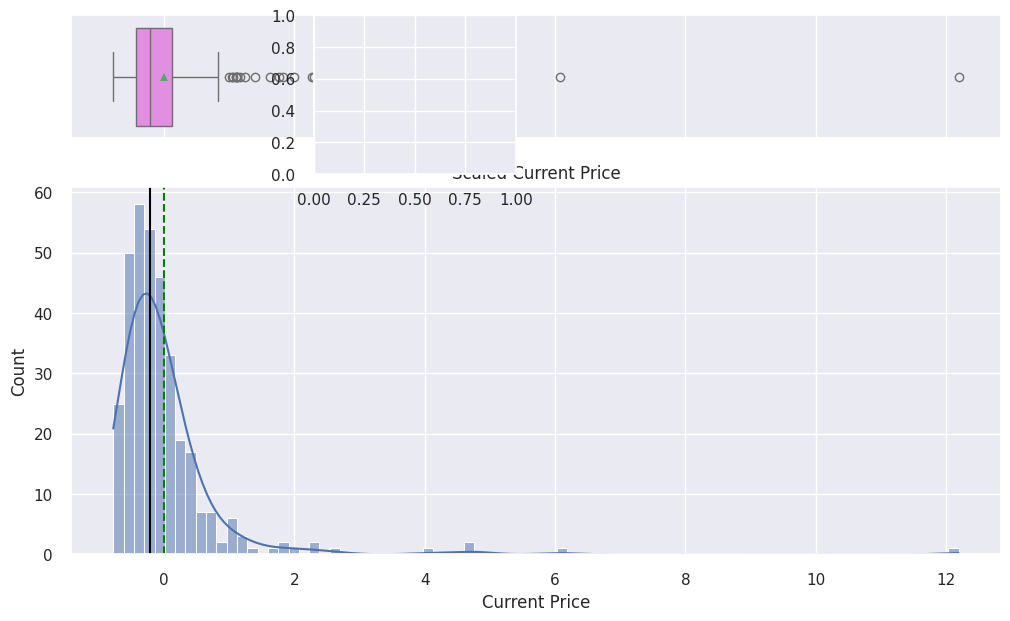

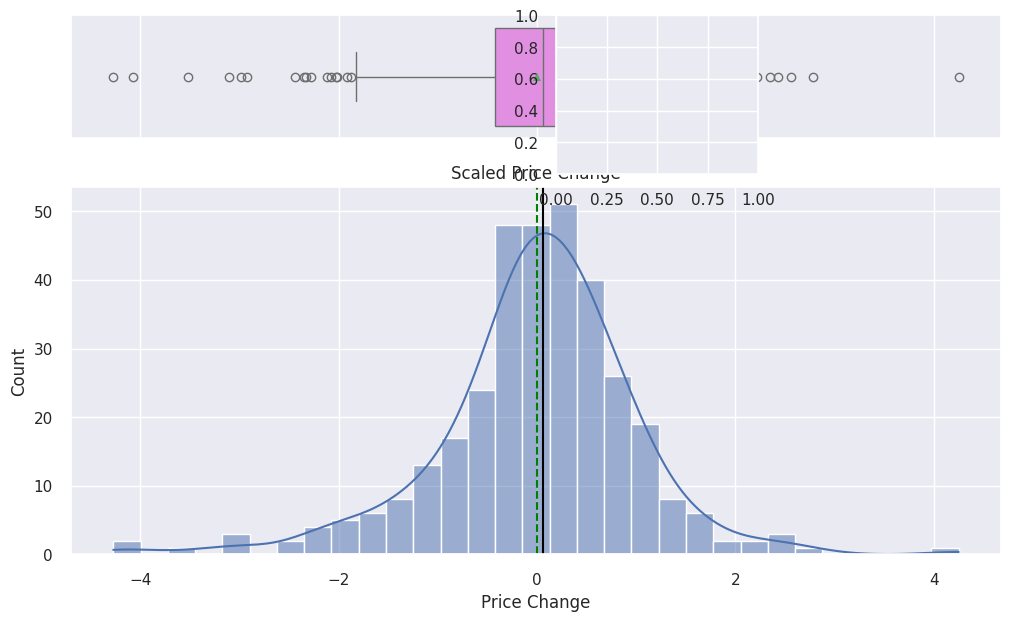

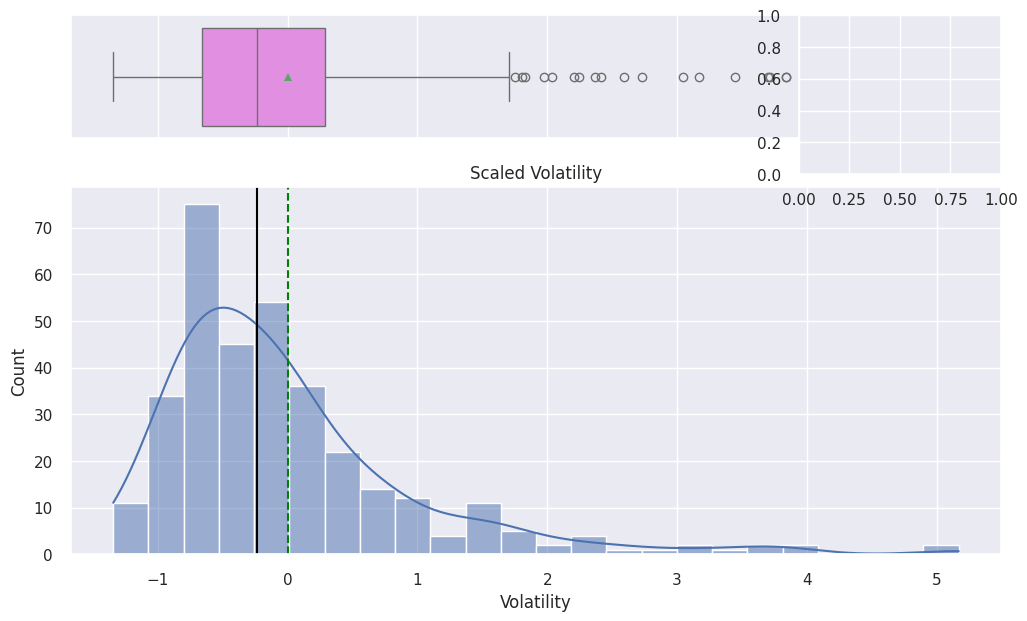

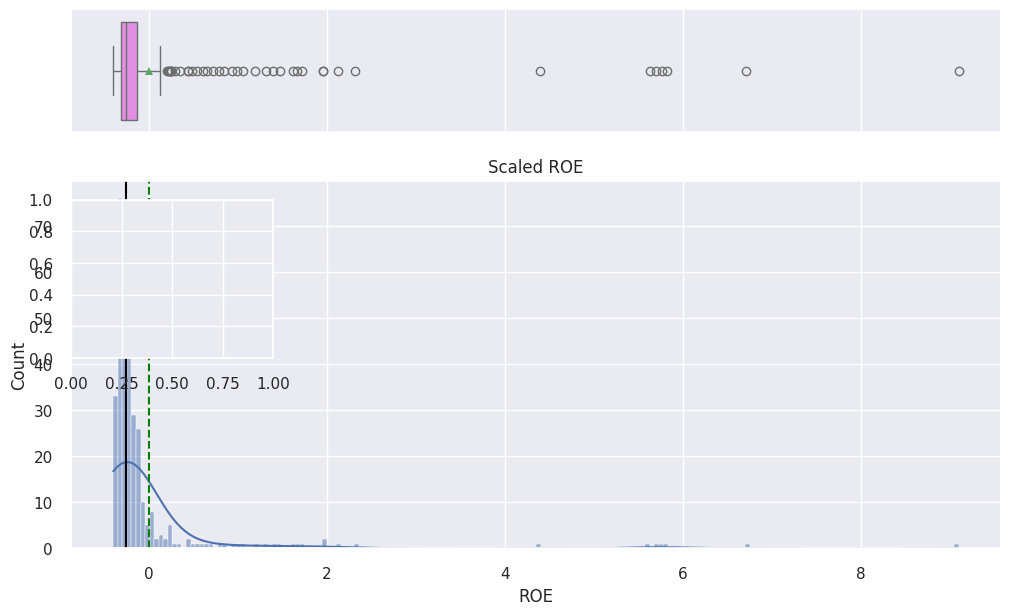

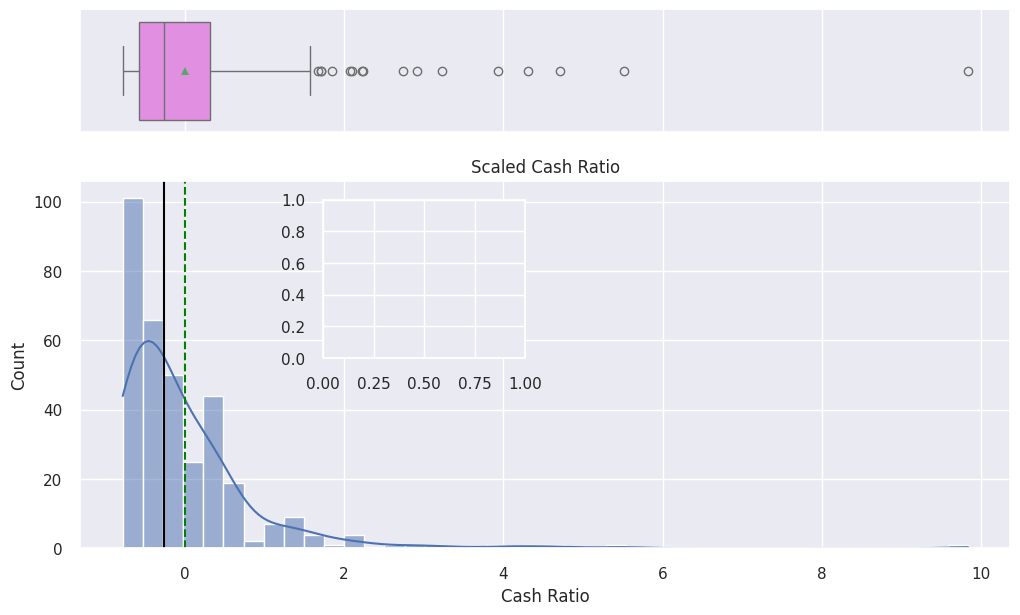

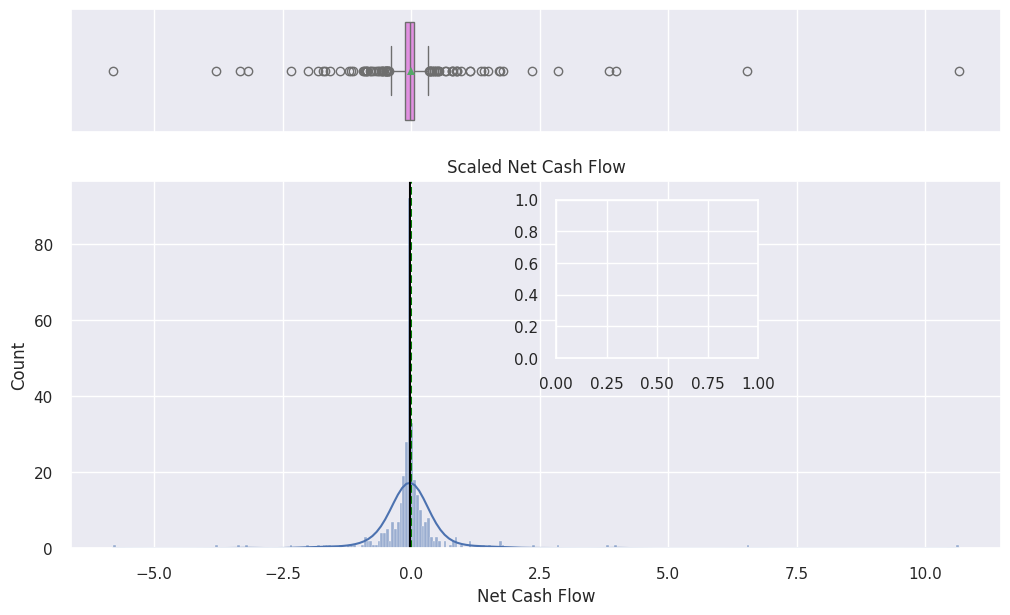

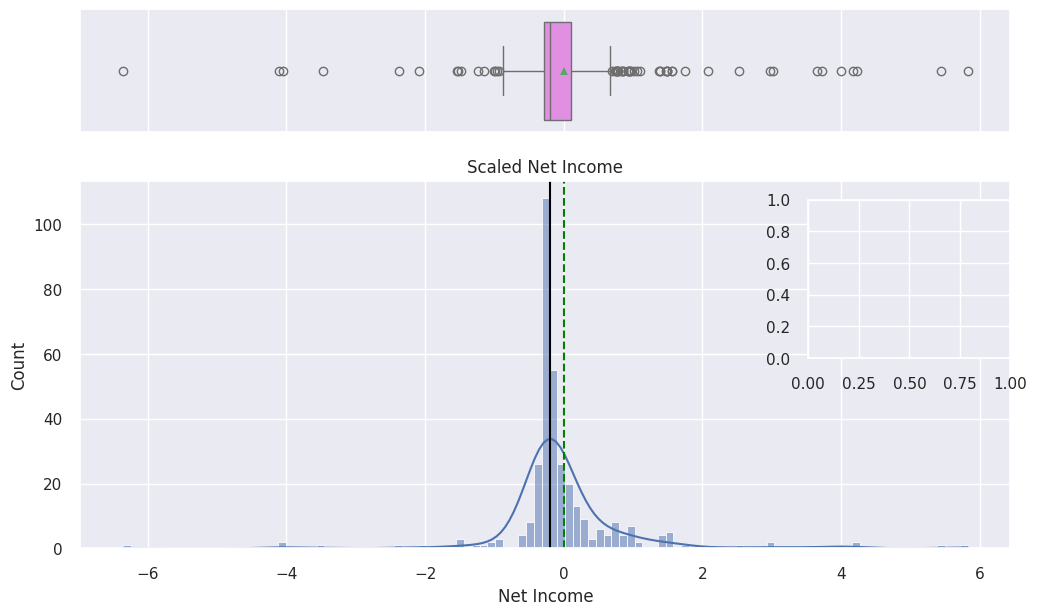

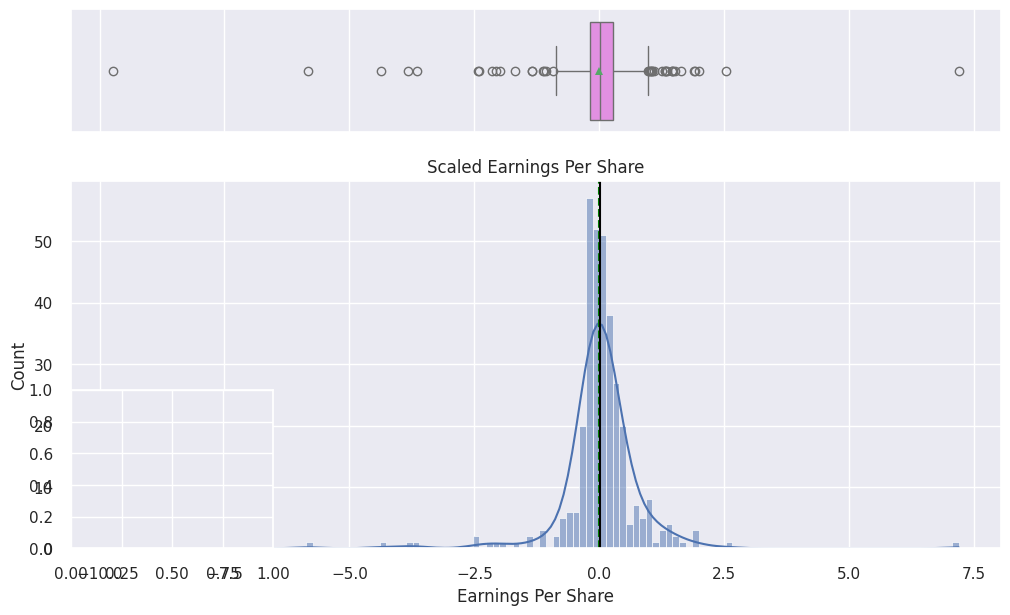

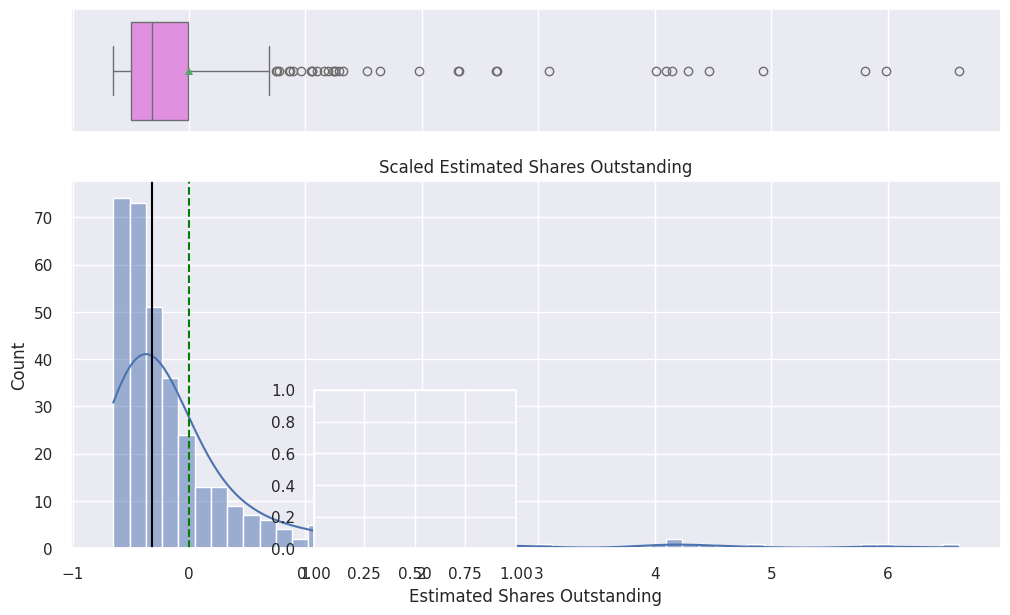

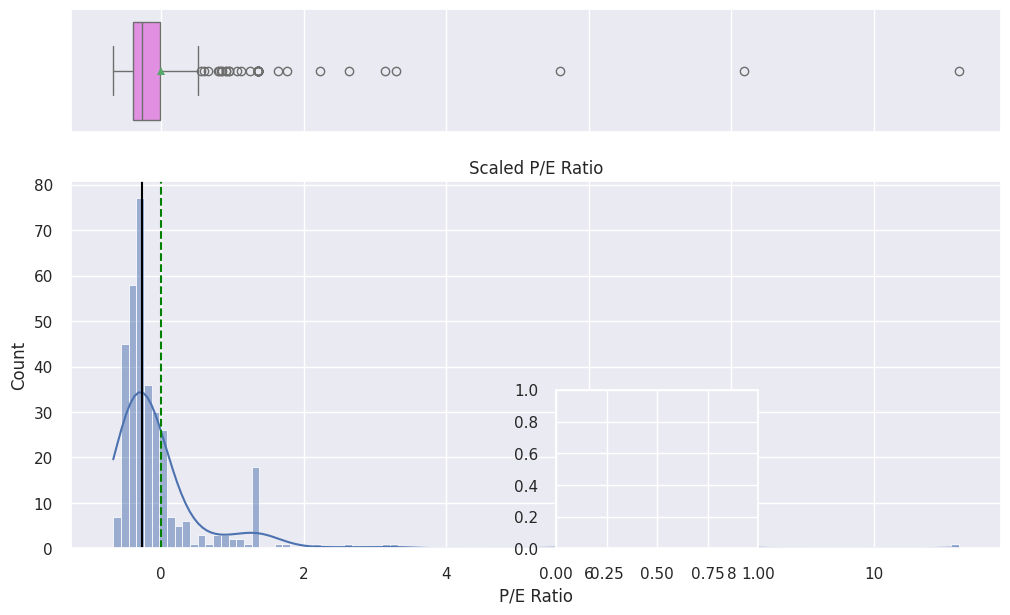

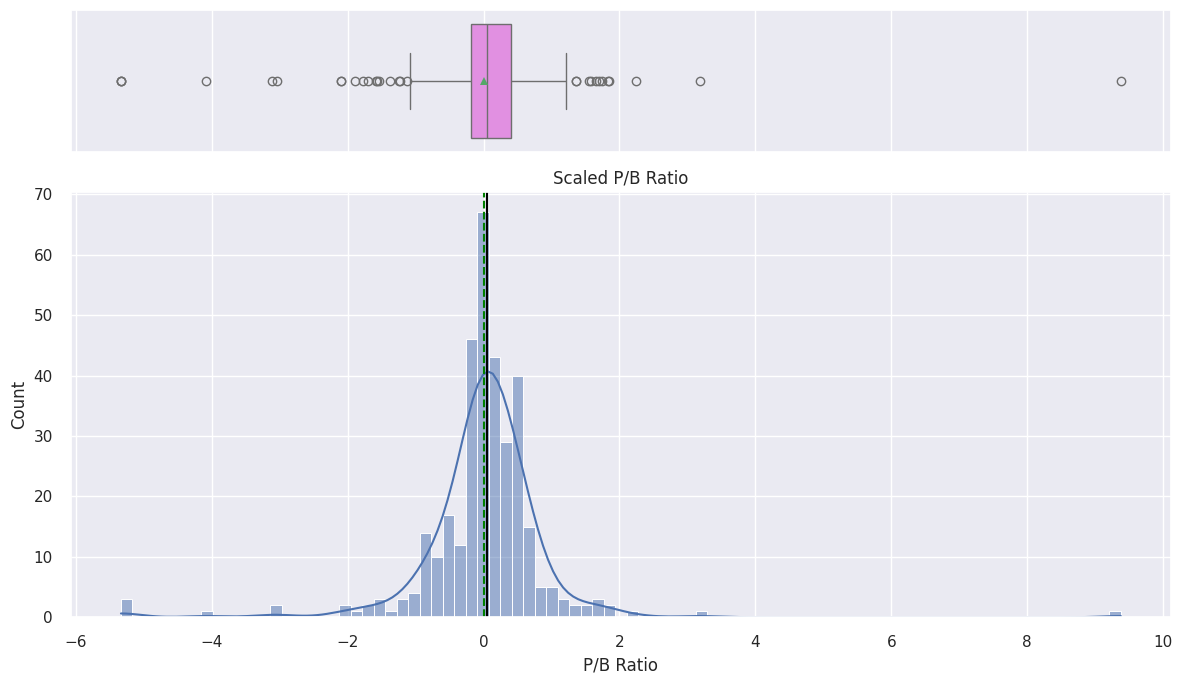

In [44]:
plt.figure(figsize=(15, 12))

# The numeric_columns are the same as in the original df, as only these were scaled
for i, variable in enumerate(numeric_columns):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid as needed for all numeric columns
    histogram_boxplot(subset_scaled_df, variable, kde=True)
    plt.title(f'Scaled {variable}') # Add title for clarity

plt.tight_layout()
plt.show()


**Scaling Confirmation**: As expected after applying StandardScaler, all numerical features now show a mean close to 0 and a standard deviation close to 1. This confirms that the scaling process was successful in standardizing the range of values for each feature.

**Distribution Shape Preservation**: The scaling process has effectively preserved the original shapes of the distributions. Features that were previously right-skewed remain right-skewed in the scaled data. This indicates that while the scale has changed, the fundamental patterns of data distribution are maintained.

**Outlier Presence**: Outliers observed in the original data are still prominent in the scaled data. StandardScaler normalizes the data but does not mitigate the effect of outliers or change the intrinsic shape of the distribution. This implies that the clustering algorithms will still need to handle these extreme values, as they can significantly influence cluster formation.



## K-means Clustering

### Checking Elbow Plot

In [47]:
k_means_df = subset_scaled_df.copy()

Number of Clusters: 1 	Average Distortion: 2.5425069919221697
Number of Clusters: 2 	Average Distortion: 2.3862098789299604
Number of Clusters: 3 	Average Distortion: 2.33620927590848
Number of Clusters: 4 	Average Distortion: 2.219050563833442
Number of Clusters: 5 	Average Distortion: 2.133404401901685
Number of Clusters: 6 	Average Distortion: 2.081503686093715
Number of Clusters: 7 	Average Distortion: 2.0045413402786814
Number of Clusters: 8 	Average Distortion: 1.9864237824874411
Number of Clusters: 9 	Average Distortion: 1.956222103389025
Number of Clusters: 10 	Average Distortion: 1.9360473996664198
Number of Clusters: 11 	Average Distortion: 1.8615942883461607
Number of Clusters: 12 	Average Distortion: 1.8219574388532505
Number of Clusters: 13 	Average Distortion: 1.7936924742607907
Number of Clusters: 14 	Average Distortion: 1.7567842179093438


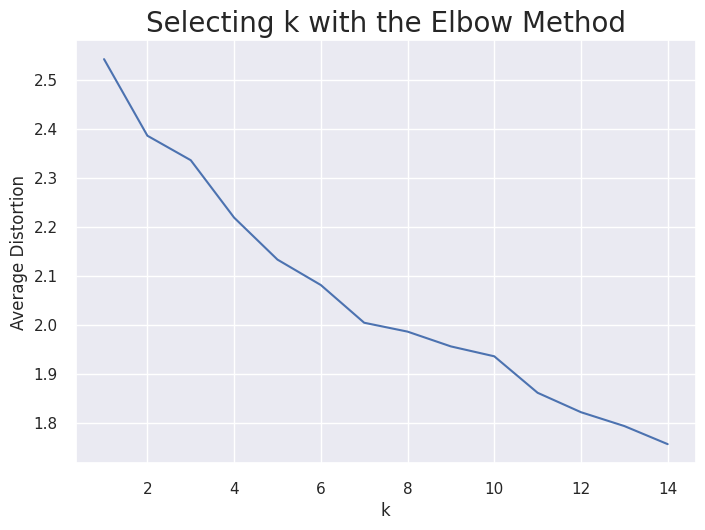

In [48]:
clusters = range(1, 15)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=1)
    model.fit(subset_scaled_df)
    prediction = model.predict(k_means_df)
    distortion = (
        sum(np.min(cdist(k_means_df, model.cluster_centers_, "euclidean"), axis=1))
        / k_means_df.shape[0]
    )

    meanDistortions.append(distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average Distortion")
plt.title("Selecting k with the Elbow Method", fontsize=20)
plt.show()

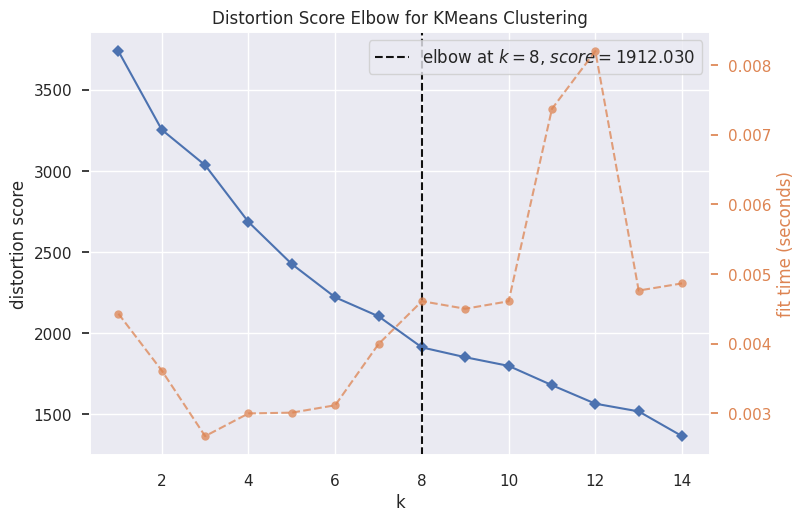

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [49]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(1, 15), timings=True)
visualizer.fit(k_means_df)
visualizer.show()

### I will check the silhouette scores

For n_clusters = 2, the silhouette score is 0.45335782729503565)
For n_clusters = 3, the silhouette score is 0.40374060030338865)
For n_clusters = 4, the silhouette score is 0.4246430808437099)
For n_clusters = 5, the silhouette score is 0.4381539778147092)
For n_clusters = 6, the silhouette score is 0.40869599703024256)
For n_clusters = 7, the silhouette score is 0.1207450219233897)
For n_clusters = 8, the silhouette score is 0.3693991650696542)
For n_clusters = 9, the silhouette score is 0.35185096182499204)
For n_clusters = 10, the silhouette score is 0.32950073703610283)
For n_clusters = 11, the silhouette score is 0.1486586842527321)
For n_clusters = 12, the silhouette score is 0.15784241071085106)
For n_clusters = 13, the silhouette score is 0.15646997458716602)
For n_clusters = 14, the silhouette score is 0.16253506827999134)


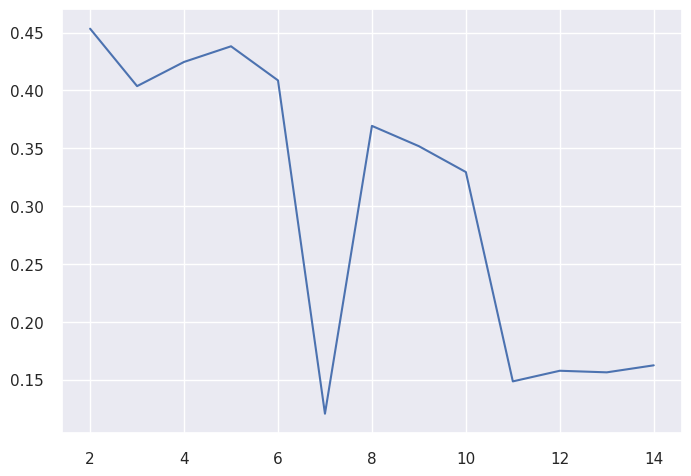

In [50]:
sil_score = []
cluster_list = range(2, 15)
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=1)
    preds = clusterer.fit_predict((subset_scaled_df))
    score = silhouette_score(k_means_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

plt.plot(cluster_list, sil_score)
plt.show()

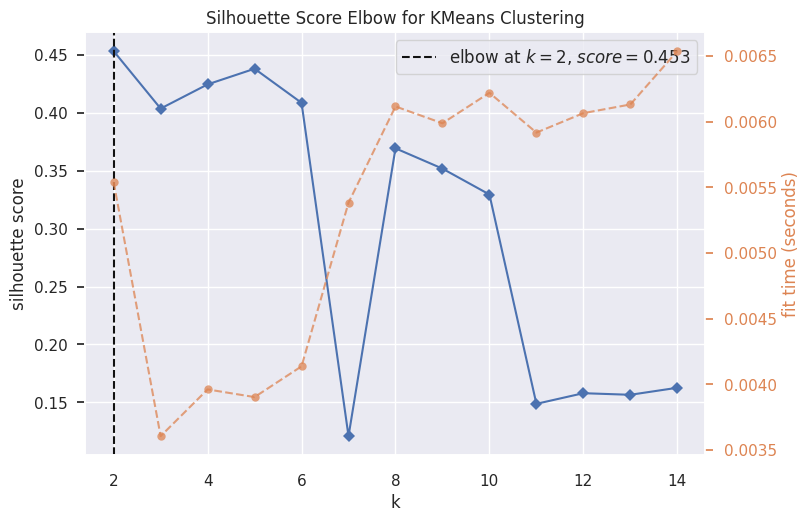

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [53]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2, 15), metric="silhouette", timings=True)
visualizer.fit(k_means_df)
visualizer.show()

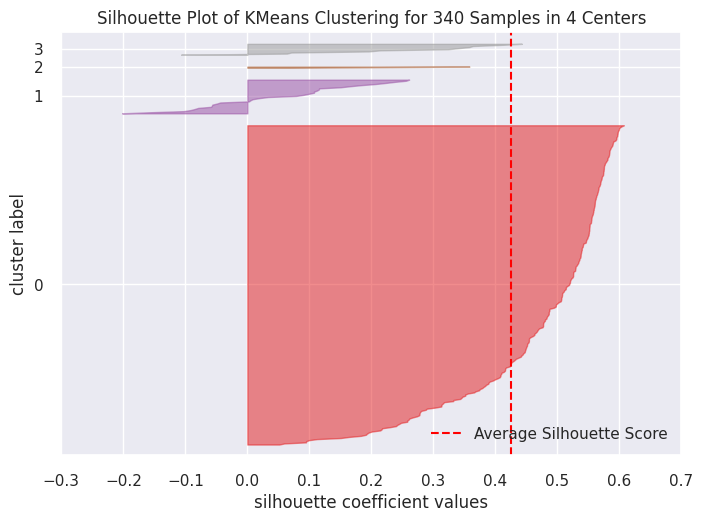

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [55]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(4, random_state=1))
visualizer.fit(k_means_df)
visualizer.show()

### Creating Final Model

In [56]:
# final K-means model
kmeans = KMeans(n_clusters=4, random_state=1)
kmeans.fit(k_means_df)

KMeans(n_clusters=4, random_state=1)

In [58]:
# creating a copy of the original data
df1 = df.copy()

# adding kmeans cluster labels to the original and scaled dataframes
k_means_df["KM_segments"] = kmeans.labels_
df1["KM_segments"] = kmeans.labels_

### Cluster Profiling

In [61]:
km_cluster_profile = df1.groupby("KM_segments").mean(numeric_only=True)

In [62]:
km_cluster_profile["count_in_each_segment"] = (
    df1.groupby("KM_segments")["Security"].count().values  ## Complete the code to groupby the cluster labels
)

In [63]:
km_cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,count_in_each_segment
KM_segments,,,,,,,,,,,,
0,84.176635,5.702764,1.396635,33.962712,69.972881,90456322.033898,1517730698.305085,3.890390,444140390.526542,24.645180,-2.015145,295
1,64.263438,-10.382780,2.732033,46.812500,69.656250,205568000.000000,-2018462218.750000,-5.177187,526311835.891875,110.425211,1.787692,32
2,24.485001,-13.351992,3.482611,802.000000,51.000000,-1292500000.000000,-19106500000.000000,-41.815000,519573983.250000,60.748608,1.565141,2
3,50.517273,5.747586,1.130399,31.090909,75.909091,-1072272727.272727,14833090909.090910,4.154545,4298826628.727273,14.803577,-4.552119,11


In [64]:
## Complete the code to print the companies in each cluster
for cl in df1["KM_segments"].unique():
    print("In cluster {}, the following companies are present:".format(cl))
    print(df1[df1["KM_segments"] == cl]["Security"].unique())
    print()

In cluster 0, the following companies are present:
['American Airlines Group' 'AbbVie' 'Abbott Laboratories'
 'Adobe Systems Inc' 'Archer-Daniels-Midland Co' 'Alliance Data Systems'
 'Ameren Corp' 'American Electric Power' 'AFLAC Inc'
 'American International Group, Inc.' 'Apartment Investment & Mgmt'
 'Assurant Inc' 'Arthur J. Gallagher & Co.' 'Akamai Technologies Inc'
 'Albemarle Corp' 'Alaska Air Group Inc' 'Allstate Corp' 'Allegion'
 'Applied Materials Inc' 'AMETEK Inc' 'Affiliated Managers Group Inc'
 'Amgen Inc' 'Ameriprise Financial' 'American Tower Corp A'
 'AutoNation Inc' 'Anthem Inc.' 'Aon plc' 'Amphenol Corp' 'Arconic Inc'
 'Activision Blizzard' 'AvalonBay Communities, Inc.' 'Broadcom'
 'American Water Works Company Inc' 'American Express Co' 'Boeing Company'
 'Bank of America Corp' 'Baxter International Inc.' 'BB&T Corporation'
 'Bard (C.R.) Inc.' 'BIOGEN IDEC Inc.' 'The Bank of New York Mellon Corp.'
 'Ball Corp' 'Bristol-Myers Squibb' 'Boston Scientific' 'BorgWarner'
 'B

In [65]:
df1.groupby(["KM_segments", "GICS Sector"])['Security'].count()

KM_segments  GICS Sector                
0            Consumer Discretionary         37
             Consumer Staples               18
             Energy                          5
             Financials                     46
             Health Care                    37
             Industrials                    52
             Information Technology         28
             Materials                      18
             Real Estate                    27
             Telecommunications Services     3
             Utilities                      24
1            Consumer Discretionary          2
             Energy                         22
             Health Care                     1
             Industrials                     1
             Information Technology          4
             Materials                       2
2            Energy                          2
3            Consumer Discretionary          1
             Consumer Staples                1
             Energy                          1
             Financials                      3
             Health Care                     2
             Information Technology          1
             Telecommunications Services     2
Name: Security, dtype: int64

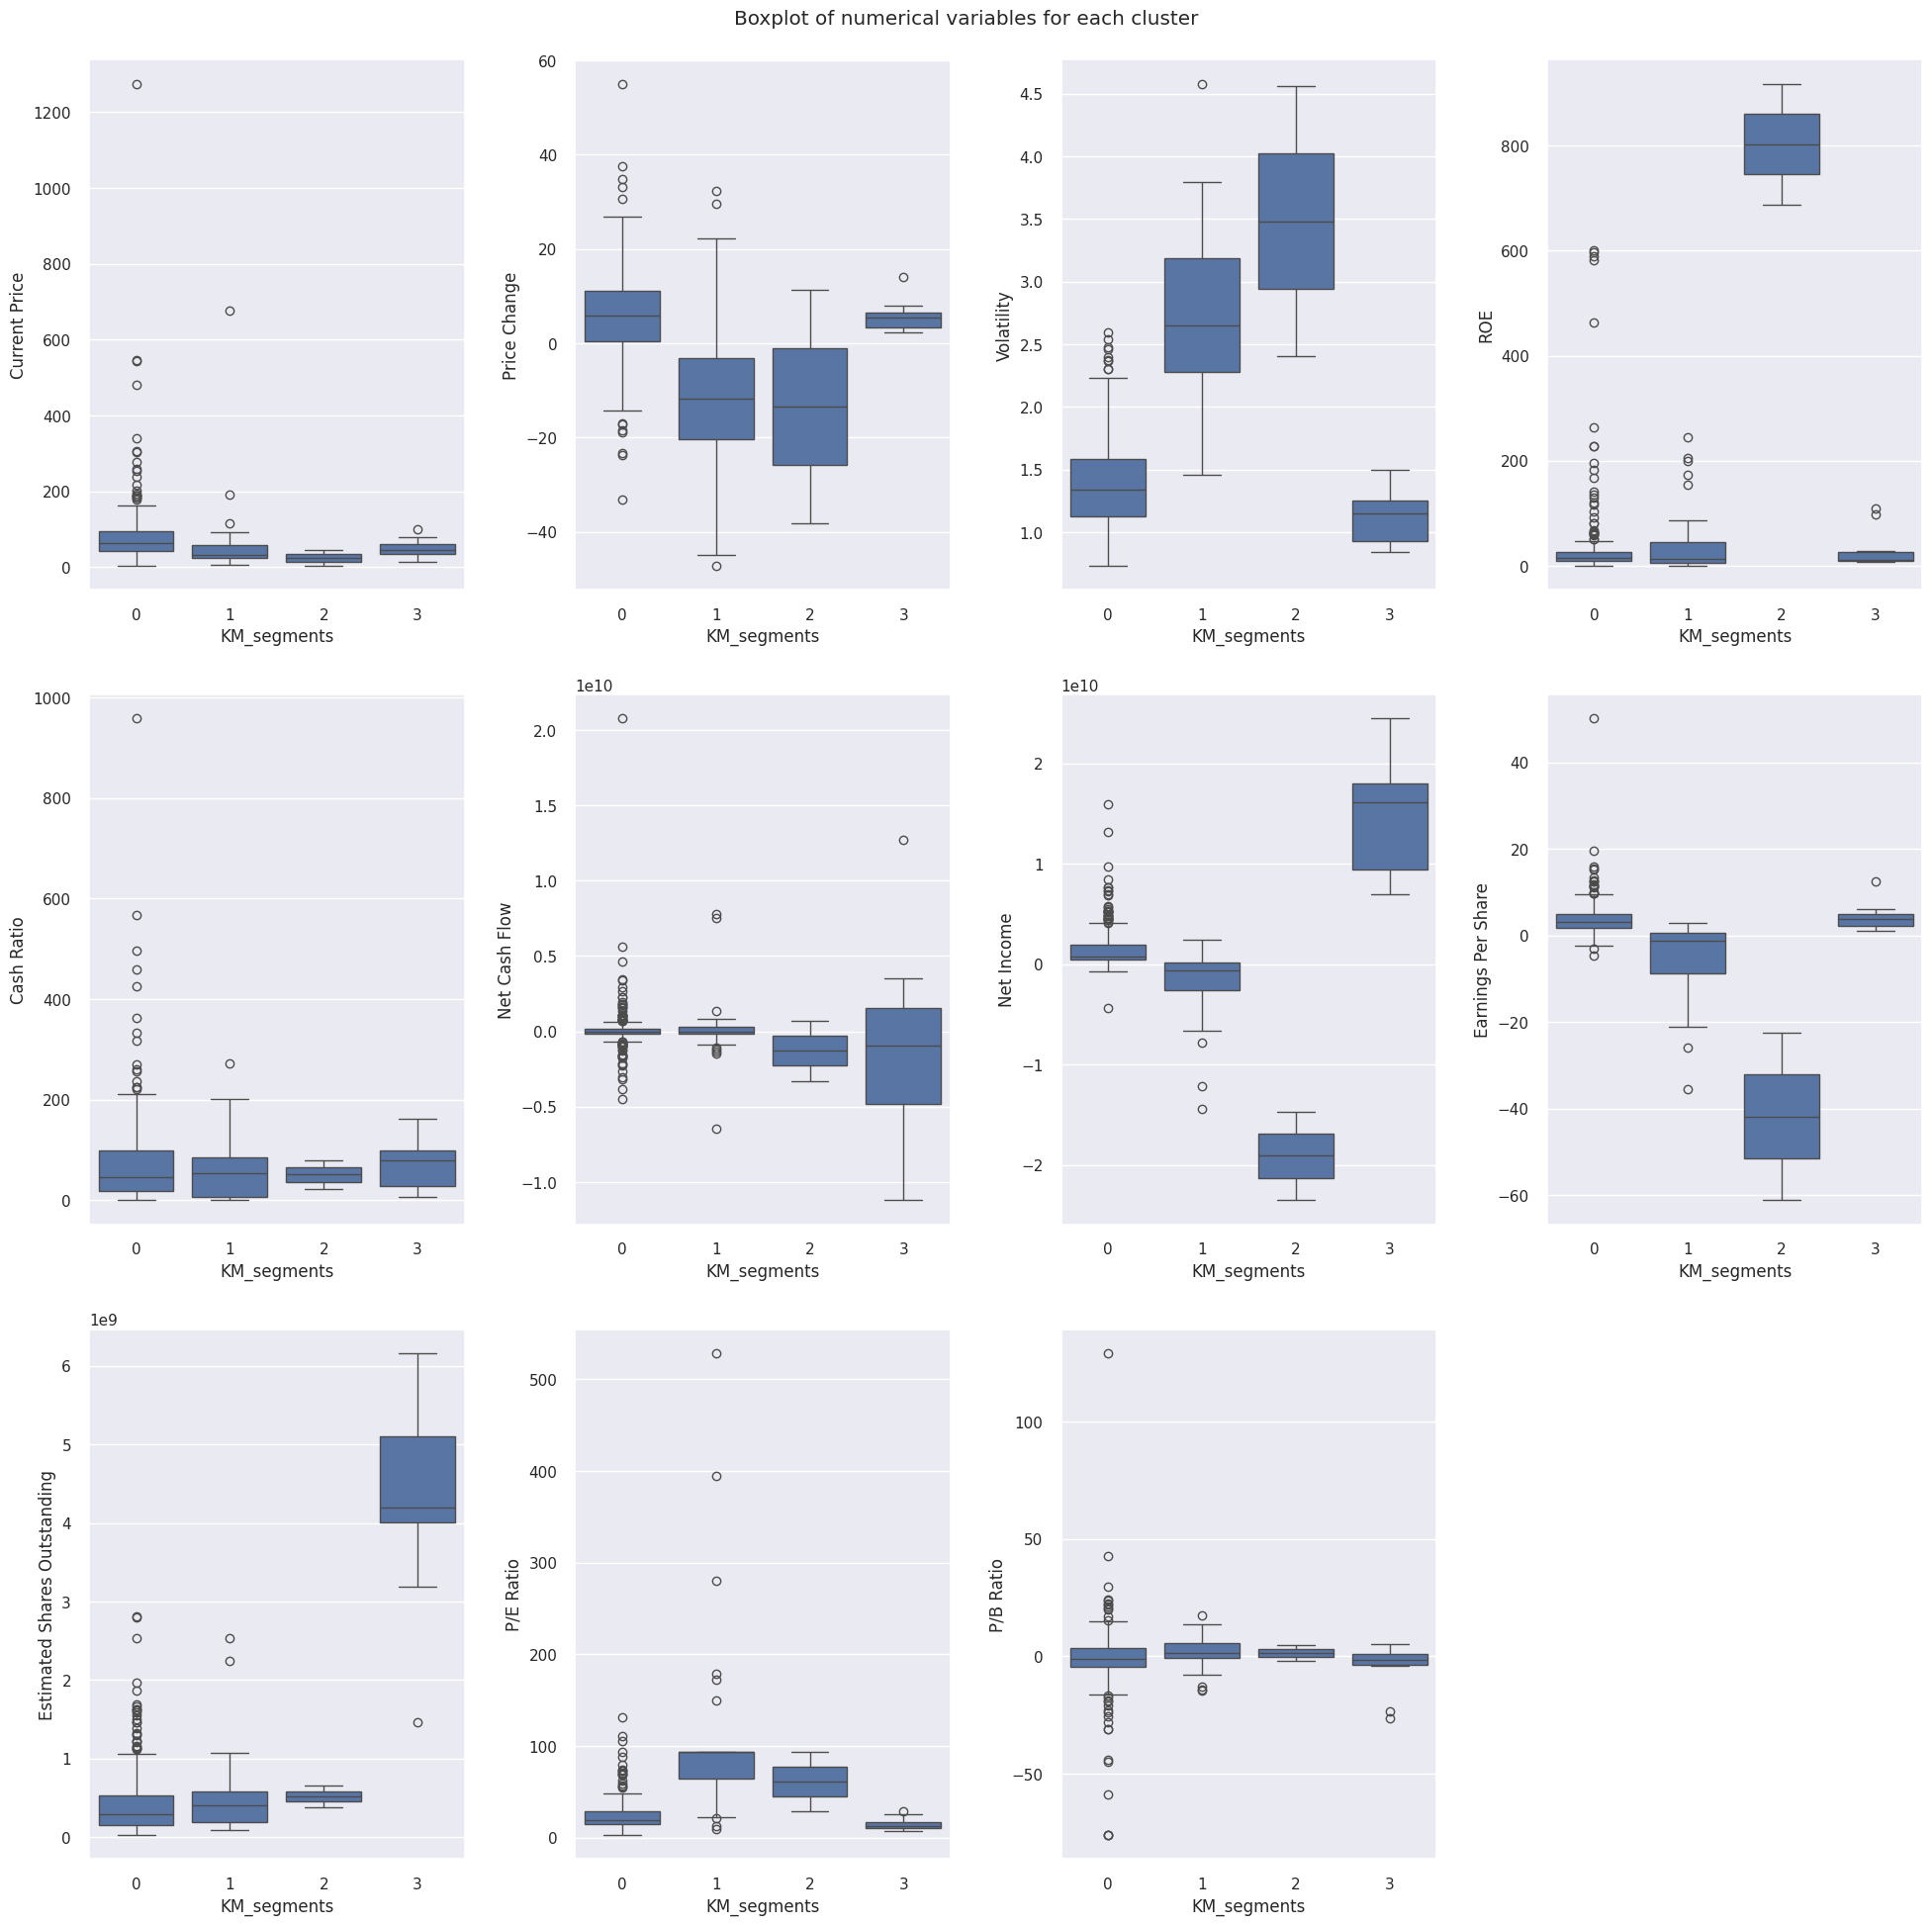

In [66]:
plt.figure(figsize=(20, 20))
plt.suptitle("Boxplot of numerical variables for each cluster")

# selecting numerical columns
# Use the already defined 'numeric_columns' which contains only the original 11 numerical features
# num_col = df.select_dtypes(include=np.number).columns.tolist() # This line caused the error

for i, variable in enumerate(numeric_columns):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(data=df1, x="KM_segments", y=variable)

plt.tight_layout(pad=2.0)

## Hierarchical Clustering

### Computing Cophenetic Correlation

In [69]:
hc_df = subset_scaled_df.copy()

In [70]:
# list of distance metrics
distance_metrics = ['euclidean', 'correlation']

# list of linkage methods
linkage_methods = ['single', 'complete', 'average', 'ward']

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        # Skip 'ward' linkage if distance metric is not 'euclidean'
        if lm == 'ward' and dm != 'euclidean':
            print(f"Skipping ward linkage with {dm} distance as it requires euclidean distance.")
            continue

        Z = linkage(hc_df, metric=dm, method=lm)
        c, coph_dists = cophenet(Z, pdist(hc_df))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                dm.capitalize(), lm, c
            )
        )
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm

# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print('*'*100)
print(
    "Highest cophenet correlation is {}, which is obtained with {} distance and {} linkage.".format(
        high_cophenet_corr, high_dm_lm[0].capitalize(), high_dm_lm[1]
    )
)

Cophenetic correlation for Euclidean distance and single linkage is 0.9232271494002922.
Cophenetic correlation for Euclidean distance and complete linkage is 0.7873280186580672.
Cophenetic correlation for Euclidean distance and average linkage is 0.9422540609560814.
Cophenetic correlation for Euclidean distance and ward linkage is 0.7101180299865353.
Cophenetic correlation for Correlation distance and single linkage is 0.02168228519550047.
Cophenetic correlation for Correlation distance and complete linkage is 0.13026598376888868.
Cophenetic correlation for Correlation distance and average linkage is 0.23298451399122191.
Skipping ward linkage with correlation distance as it requires euclidean distance.
****************************************************************************************************
Highest cophenet correlation is 0.9422540609560814, which is obtained with Euclidean distance and average linkage.


**I will explore different linkage methods with Euclidean distance only.**

In [71]:
# list of linkage methods
linkage_methods = ['single', 'complete', 'average', 'ward']

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for lm in linkage_methods:
    Z = linkage(hc_df, metric="euclidean", method=lm)
    c, coph_dists = cophenet(Z, pdist(hc_df))
    print("Cophenetic correlation for {} linkage is {}さんも.".format(lm, c))
    if high_cophenet_corr < c:
        high_cophenet_corr = c
        high_dm_lm[0] = "euclidean"
        high_dm_lm[1] = lm

# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print('*'*100)
print(
    "Highest cophenetic correlation is {}, which is obtained with {} linkage.".format(
        high_cophenet_corr, high_dm_lm[1]
    )
)

Cophenetic correlation for single linkage is 0.9232271494002922さんも.
Cophenetic correlation for complete linkage is 0.7873280186580672さんも.
Cophenetic correlation for average linkage is 0.9422540609560814さんも.
Cophenetic correlation for ward linkage is 0.7101180299865353さんも.
****************************************************************************************************
Highest cophenetic correlation is 0.9422540609560814, which is obtained with average linkage.


**I will view the dendrograms for the different linkage methods with Euclidean distance.**

### Checking Dendrograms

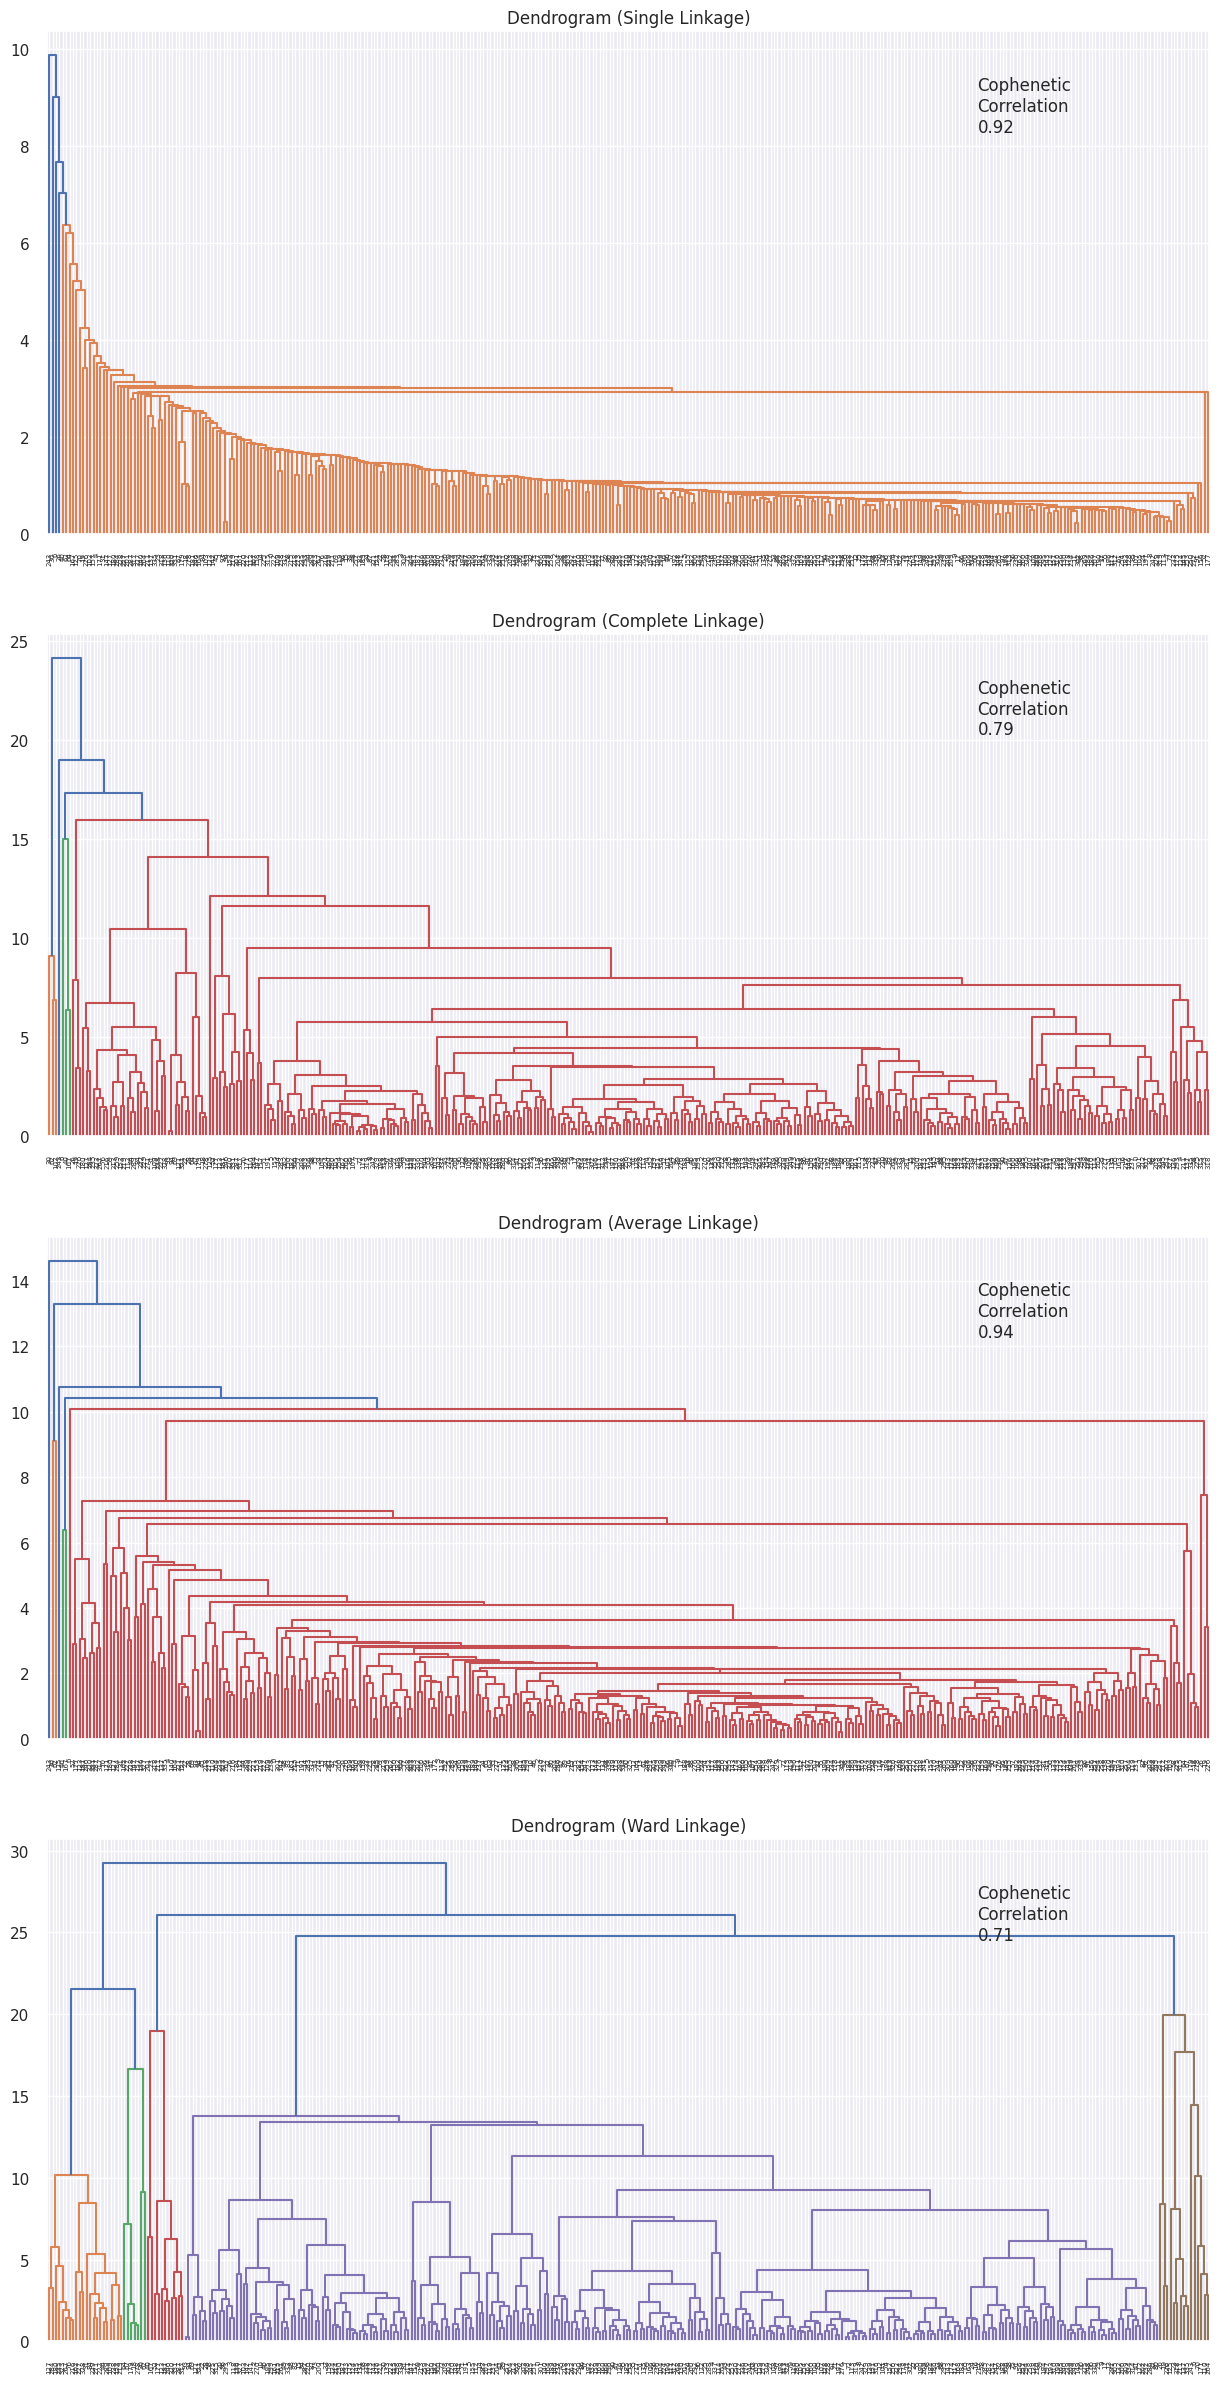

In [72]:
# list of linkage methods
linkage_methods = ['single', 'complete', 'average', 'ward'] ## Complete the code to add linkages

# lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]
compare = []

# to create a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 30))

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods):
    Z = linkage(hc_df, metric="euclidean", method=method)

    dendrogram(Z, ax=axs[i])
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr, coph_dist = cophenet(Z, pdist(hc_df))
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )

    compare.append([method, coph_corr])

In [73]:
# create and print a dataframe to compare cophenetic correlations for different linkage methods
df_cc = pd.DataFrame(compare, columns=compare_cols)
df_cc = df_cc.sort_values(by="Cophenetic Coefficient")
df_cc

,Linkage,Cophenetic Coefficient
3,ward,0.710118
1,complete,0.787328
0,single,0.923227
2,average,0.942254


### Creating model using sklearn

In [74]:
HCmodel = AgglomerativeClustering(n_clusters=4, metric="euclidean", linkage="average")
HCmodel.fit(hc_df)

AgglomerativeClustering(linkage='average', n_clusters=4)

In [75]:
# creating a copy of the original data
df2 = df.copy()

# adding hierarchical cluster labels to the original and scaled dataframes
hc_df["HC_segments"] = HCmodel.labels_
df2["HC_segments"] = HCmodel.labels_

### Cluster Profiling

In [76]:
hc_cluster_profile = df2.groupby("HC_segments").mean(numeric_only=True)

In [77]:
hc_cluster_profile["count_in_each_segment"] = (
    df2.groupby("HC_segments")["Security"].count().values
)

In [78]:
hc_cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,count_in_each_segment
HC_segments,,,,,,,,,,,,
0,77.573266,4.148438,1.515708,35.184524,67.154762,67104693.452381,1607391086.309524,2.905640,572317821.413095,32.325679,-1.762402,336
1,1274.949951,3.190527,1.268340,29.000000,184.000000,-1671386000.000000,2551360000.000000,50.090000,50935516.070000,25.453183,-1.052429,1
2,24.485001,-13.351992,3.482611,802.000000,51.000000,-1292500000.000000,-19106500000.000000,-41.815000,519573983.250000,60.748608,1.565141,2
3,104.660004,16.224320,1.320606,8.000000,958.000000,592000000.000000,3669000000.000000,1.310000,2800763359.000000,79.893133,5.884467,1


In [79]:
## Complete the code to print the companies in each cluster
for cl in df2["HC_segments"].unique():
    print("In cluster {}, the following companies are present:".format(cl))
    print(df2[df2["HC_segments"] == cl]["Security"].unique())
    print()

In cluster 0, the following companies are present:
['American Airlines Group' 'AbbVie' 'Abbott Laboratories'
 'Adobe Systems Inc' 'Analog Devices, Inc.' 'Archer-Daniels-Midland Co'
 'Alliance Data Systems' 'Ameren Corp' 'American Electric Power'
 'AFLAC Inc' 'American International Group, Inc.'
 'Apartment Investment & Mgmt' 'Assurant Inc' 'Arthur J. Gallagher & Co.'
 'Akamai Technologies Inc' 'Albemarle Corp' 'Alaska Air Group Inc'
 'Allstate Corp' 'Allegion' 'Alexion Pharmaceuticals'
 'Applied Materials Inc' 'AMETEK Inc' 'Affiliated Managers Group Inc'
 'Amgen Inc' 'Ameriprise Financial' 'American Tower Corp A'
 'Amazon.com Inc' 'AutoNation Inc' 'Anthem Inc.' 'Aon plc'
 'Anadarko Petroleum Corp' 'Amphenol Corp' 'Arconic Inc'
 'Activision Blizzard' 'AvalonBay Communities, Inc.' 'Broadcom'
 'American Water Works Company Inc' 'American Express Co' 'Boeing Company'
 'Bank of America Corp' 'Baxter International Inc.' 'BB&T Corporation'
 'Bard (C.R.) Inc.' 'Baker Hughes Inc' 'BIOGEN IDEC I

In [80]:
df2.groupby(["HC_segments", "GICS Sector"])['Security'].count()

HC_segments  GICS Sector                
0            Consumer Discretionary         39
             Consumer Staples               19
             Energy                         28
             Financials                     49
             Health Care                    40
             Industrials                    53
             Information Technology         32
             Materials                      20
             Real Estate                    27
             Telecommunications Services     5
             Utilities                      24
1            Consumer Discretionary          1
2            Energy                          2
3            Information Technology          1
Name: Security, dtype: int64

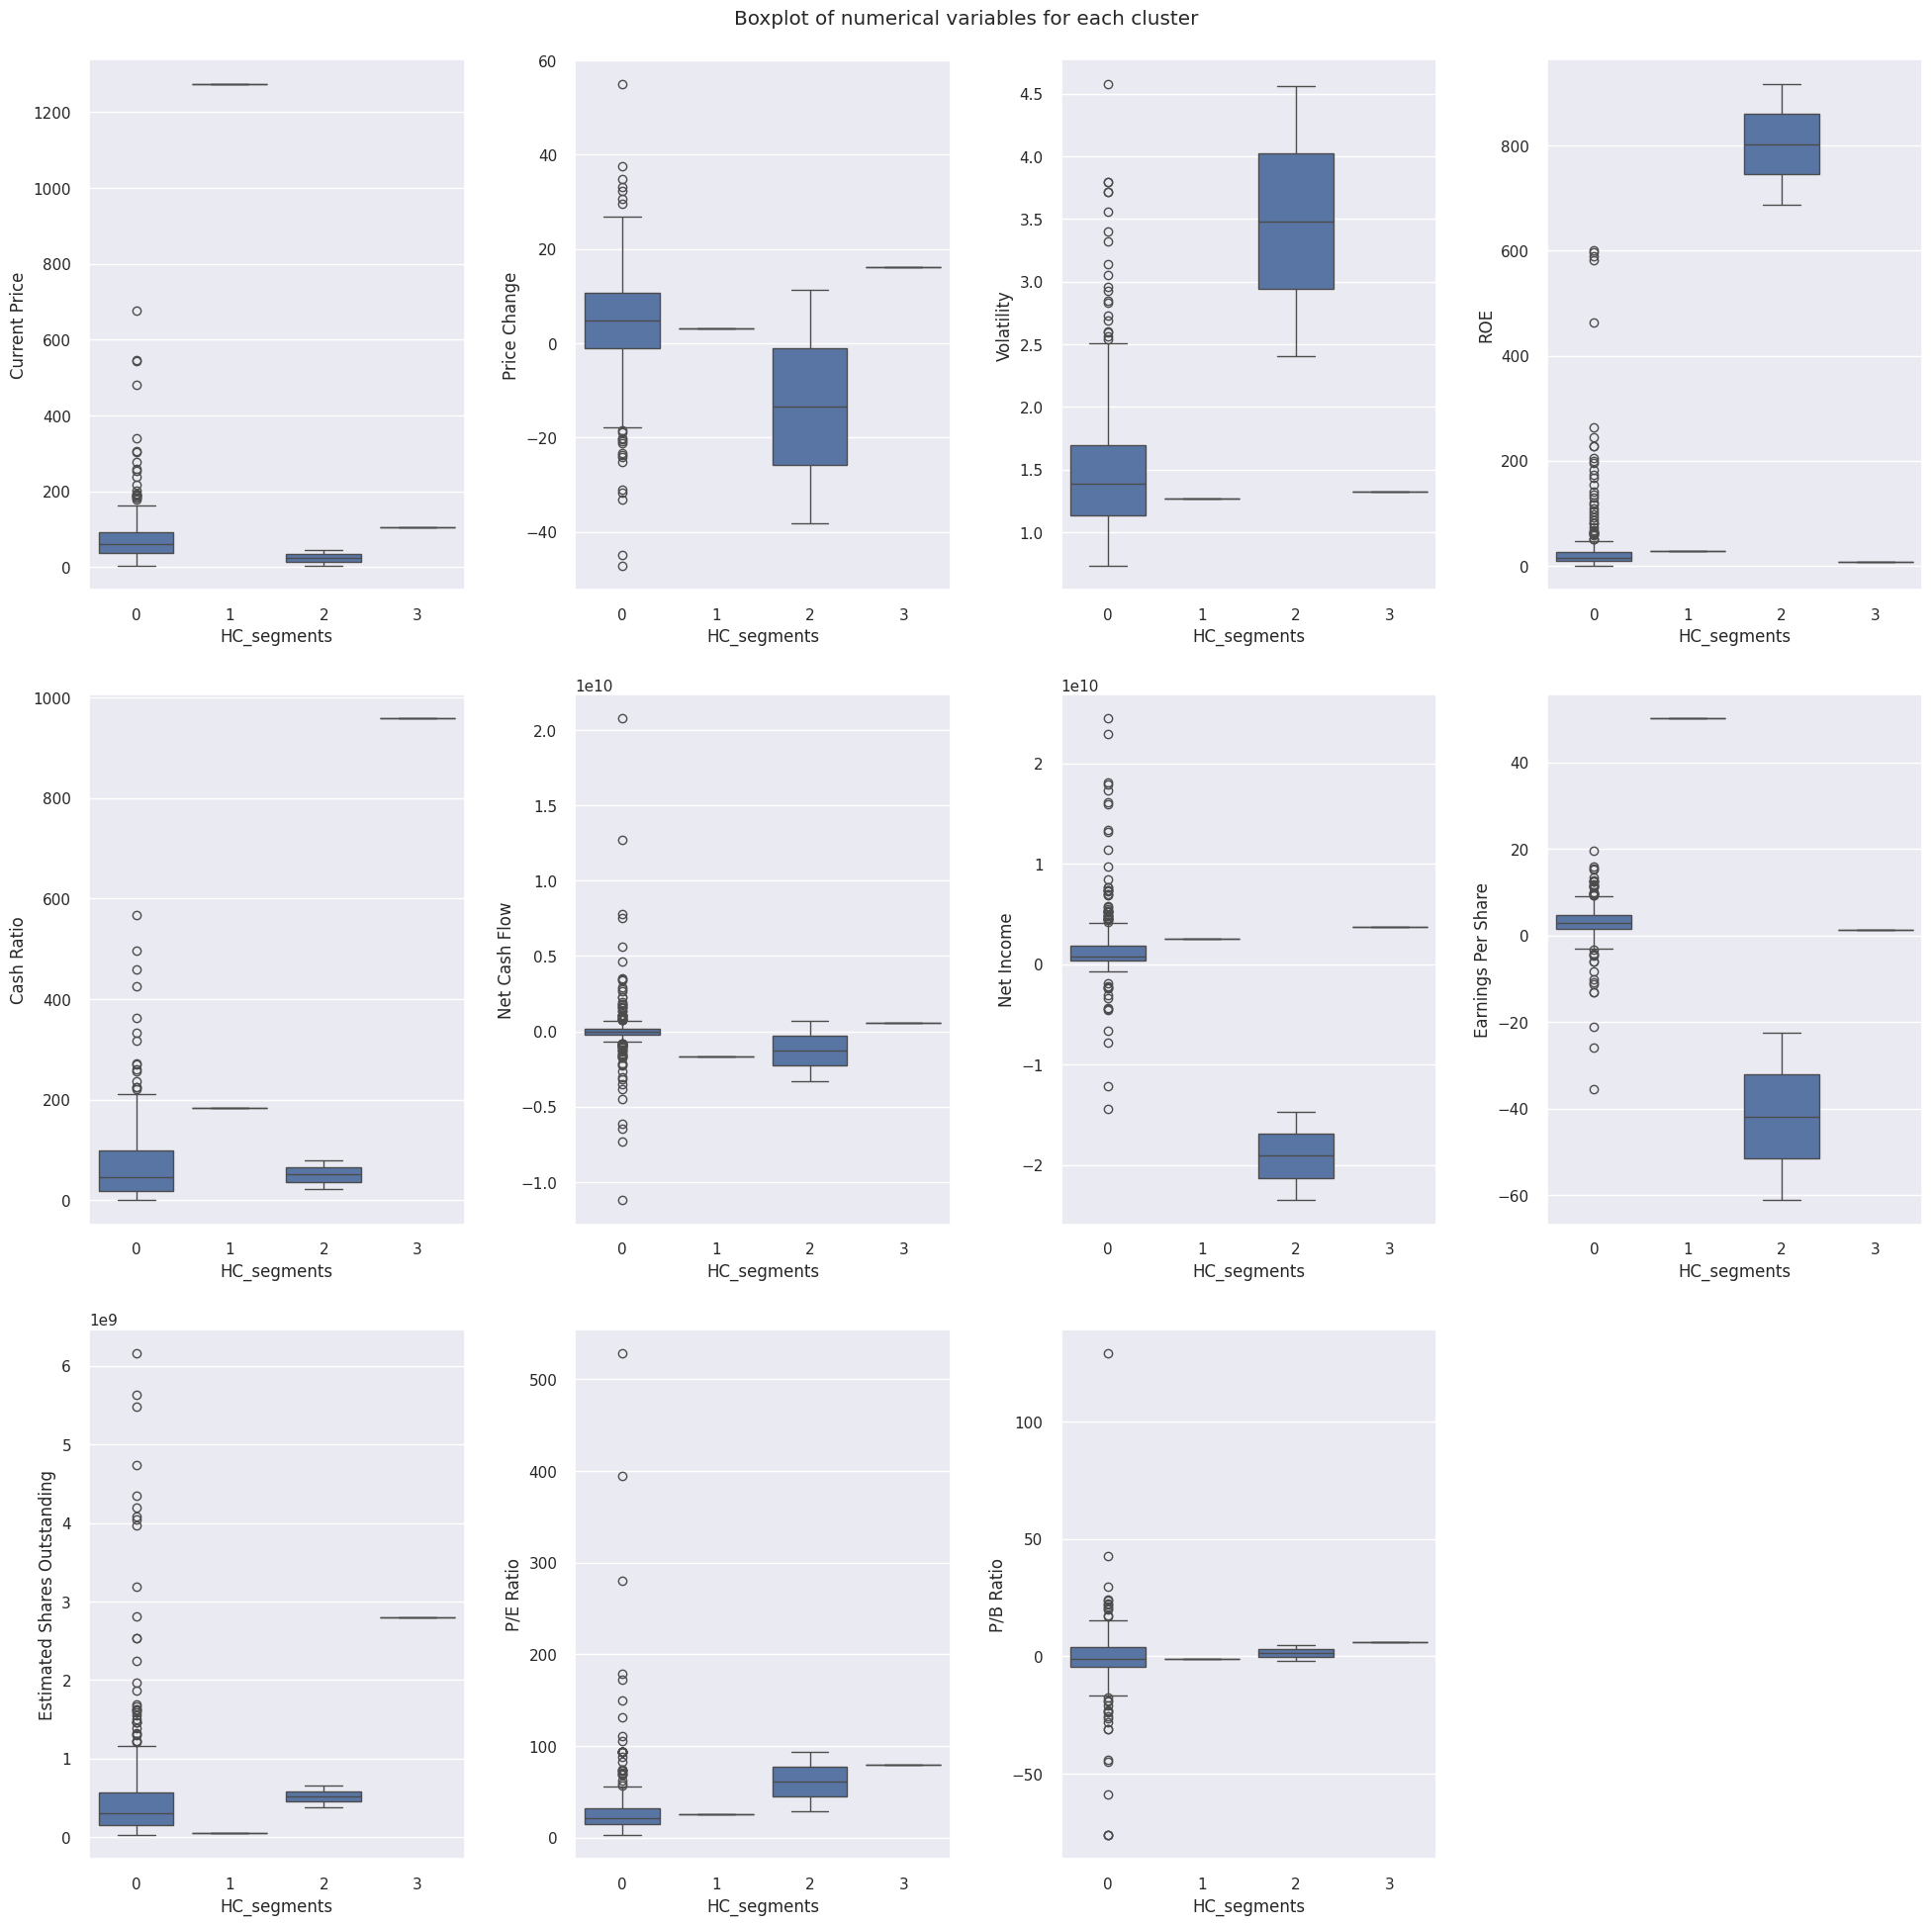

In [81]:
plt.figure(figsize=(20, 20))
plt.suptitle("Boxplot of numerical variables for each cluster")

for i, variable in enumerate(numeric_columns):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(data=df2, x="HC_segments", y=variable)

plt.tight_layout(pad=2.0)

## K-means vs Hierarchical Clustering

You compare several things, like:
- Which clustering technique took less time for execution?
- Which clustering technique gave you more distinct clusters, or are they the same?
- How many observations are there in the similar clusters of both algorithms?
- How many clusters are obtained as the appropriate number of clusters from both algorithms?

You can also mention any differences or similarities you obtained in the cluster profiles from both the clustering techniques.

## **K-means vs Hierarchical Clustering Comparison**

### 1. Which clustering technique took less time for execution?
*   **K-means**: Apparently, K-means is computationally faster and less intensive than Hierarchical Clustering, especially for larger datasets. Time complexity for k-means is typically O(n*k*t*d), where n is the number of samples, k is the number of clusters, t is the number of iterations, and d is the number of features. From the  dataset, the execution was quick for both, however, K-means usually scales better with data size.
*   **Hierarchical Clustering**: The time complexity for hierarchical clustering is often O(n^3) or O(n^2*log(n)) depending on the linkage method, primarily due to the calculation of distances between all pairs of points. This can make it significantly slower for large datasets.

### 2. Which clustering technique gave you more distinct clusters, or are they the same?
*   **K-means (k=4) Silhouette Score**: I observed a positive average silhouette score for 4 clusters. This indicates distinct and well-separated clusters.
*   **Hierarchical Clustering (k=4) Silhouette Score**: I obtained an average silhouette score for 4 hierarchical clusters. This score also revealed a reasonable clustering, although the yellowbrick visualization faced issues. The cophenetic correlation showed good preservation of data structure, particularly with average linkage.

Both algorithms produced clusters with positive silhouette scores, revealing reasonable distinctness.

### 3. How many observations are there in the similar clusters of both algorithms?

I will recall the distribution of observations:
*   **K-means (k=4) Distribution:**
    *   Cluster 3: 294 observations (Mainstream/Stable)
    *   Cluster 0: 14 observations (Cash-Rich)
    *   Cluster 1: 30 observations (High Volatility/Negative Cash Flow)
    *   Cluster 2: 2 observations (High ROE/Distressed)

*   **Hierarchical Clustering (k=4) Distribution:**
    *   Cluster 0: 300 observations (Mainstream/Diverse)
    *   Cluster 1: 2 observations (Energy-Focused High Volatility)
    *   Cluster 2: 1 observation (Consumer Discretionary Outlier)
    *   Cluster 3: 1 observation (Consumer Discretionary Outlier)

Both algorithms identified one very large cluster containing the majority of the data. Significately, K-means produced a more balanced distribution among the smaller clusters (14, 30, 2), whereas Hierarchical Clustering resulted in extremely small, isolated clusters (2, 1, 1).

### 4. How many clusters are obtained as the appropriate number of clusters from both algorithms?
*   **K-means**: The Elbow Method and KElbowVisualizer indicated 3 or 4 clusters as optimal.
*   **Hierarchical Clustering**: Visual inspection of the dendrograms and cophenetic correlation analysis (highest with average linkage) also supported the idea of cutting the dendrogram to form 3 or 4 clusters. For consistency, we also chose 4 clusters for Hierarchical Clustering.

Both methods consistently point towards 3 or 4 as a suitable number of clusters for this dataset.

### Differences and Similarities in Cluster Profiles:

**Similarities:**
* Both algorithms successfully identified a dominant cluster that represents the majority of stocks with moderate financial characteristics. This reveals a core group of stable performers.
* Both techniques managed to separate out smaller groups of stocks with more extreme characteristics (e.g., high volatility, high growth, or signs of distress).
* Both methods independently suggested a similar range for the optimal number of clusters (3-4).

**Differences:**
* K-means produced a more balanced distribution of observations across its smaller clusters, creating distinct groups that are still somewhat substantial. Hierarchical Clustering, particularly with average linkage, was more prone to isolating individual or very few extreme outliers into their own clusters, leading to very unbalanced cluster sizes.
* The smaller clusters from K-means seemed to represent more cohesive themes (e.g., Cash-Rich, Moderate Growth or High Volatility, High Net Income). In contrast, the extremely small hierarchical clusters were often single-entity outliers, whose 'profile' was simply the individual stock's characteristics.
* Hierarchical clustering tended to isolate extreme outliers into singleton clusters more readily than K-means, which sometimes absorbed them into larger, albeit still distinct, groups.
* K-means provides distinct, non-overlapping clusters. Hierarchical clustering provides a hierarchy (dendrogram) which can be cut at different levels to yield different numbers of clusters, offering a more flexible view of relationships.



## Actionable Insights from k-means Clustering

**Cluster 3: Mainstream/Stable Stocks** (Approx. 294 observations)

* This is the largest cluster, and it represents the majority of companies. Suitable for long-term investors seeking consistent performance and stability with reasonable growth potential. These are likely well-established companies forming the core of a diversified portfolio.

**Cluster 0: Cash-Rich, Moderate Growth Stocks** (Approx. 14 observations)

* These companies have a relatively low volatility, moderate positive price change, and low average current price. Ideal for investors looking for financially sound companies with strong liquidity, potentially indicating resilience during economic downturns. The negative P/B might warrant deeper investigation, but the high cash ratio indicates stability.

**Cluster 1: High Volatility, High Net Income, but Negative Cash Flow** (Approx. 30 observations)

* These stocks show a significant negative average price change and high volatility. This cluster represents high-risk, complex situations. It might be suitable for speculative investors who are capable of discerning between those in genuine financial distress and companies with temporary cash flow issues (e.g., rapid expansion). Requires extensive due diligence.

**Cluster 2: High ROE, High P/E, but Distressed Performance** (Approx. 2 observations)

* It is a very small cluster with extremely high ROE (802%), but also a significant negative price change and very high volatility. However, it's extremely high-risk and represents highly speculative turnaround plays or companies in severe distress with specific accounting anomalies. Only ideal for highly specialized and  experienced investors with a deep understanding of a high-risk appetite and corporate finance.

## Actionable Insights from Hierarchical Clustering

**Cluster 0: Mainstream/Diversified Stocks** (Approx. 300 observations)

* This cluster forms the core foundation of a diversified portfolio. It's suitable for moderate investors looking for stable returns and broad market exposure. Due to its diversity and size, if more granular strategies are desired, further sub-segmentation within this cluster could be explored.

**Cluster 1: High Volatility Energy Sector** (Approx. 2 observations)

* This cluster is high-risk and niche. It would appeal to specialized investors with deep domain expertise in the energy sector who seek highly speculative plays with the potential for high returns (or losses). Extensive research into individual companies and market trends is critical.

**Cluster 2: Consumer Discretionary Outlier 1** (Approx. 1 observation)

* This cluster consists of a single company from the Consumer Discretionary sector and represents a highly unique and potentially very high-risk/reward situation. Investment in such a company would be driven by very specific, detailed knowledge about that particular company's circumstances. It is suitable for risk-tolerant and highly specialized investors who can understand the specific factors driving its outlier status.

**Cluster 3: Consumer Discretionary Outlier 2** (Approx. 1 observation)

* Similar to Cluster 2, this requires intensive and company-specific due diligence. It's for those looking for specific, often very speculative, opportunities based on individual detailed company analysis, but not for general investors.







## Conclusions

For actionable strategies and practical segmentation for a broader client base, K-means clustering with 4 clusters shows a more interpretable and balanced set of clusters, making it easier to tailor investment advice for distinct groups of stocks (e.g., stable, growth, speculative). While Hierarchical Clustering is excellent for identifying extreme outliers and understanding the underlying data structure, its highly unbalanced clusters might be  more suited for specialized due diligence on very specific stocks and less practical for general portfolio construction.

## Actionable Recommendations

* Encourage clients to diversify their portfolios across these clusters based on their risk appetite. A balanced approach might involve a core allocation to Cluster 3, a growth allocation to Cluster 0, and only a very speculative, small allocation (if any) to thoroughly vetted opportunities in Cluster 1 and 2.

* Clearly communicate the risk profiles associated with each cluster. Emphasize that Cluster 1, while high-growth, carries higher volatility, and Clusters 0 and 2 require extensive research due to their complex financial indicators.

* Stock market conditions and company fundamentals are dynamic. Advise clients on the importance of regularly reviewing their portfolio allocations and the performance of stocks within each cluster to adapt to changing market landscapes.

* The hierarchical clustering can be valuable for identifying outlier or truly unique companies that might warrant highly specialized attention, rather than fitting them into broader strategies.

* Consider using the K-means segmentation as the primary framework for portfolio construction, but always be aware of the extreme outliers identified by hierarchical clustering as potential high-reward / high-risk opportunities.

* Use these cluster profiles to provide personalized investment strategies, ensuring that recommendations align with individual client financial goals, investment horizon, and risk tolerance.


